# 12-04 TabPFN-SHAP-Interpretation ohne Refitting

Dieses Notebook interpretiert die finalen Standard-Predictions aus `12-03_TabPFN_Final_Test_Three_Targets_2024_2025.ipynb` mit SHAP.

Die wichtigste Regel dieses Notebooks ist: Es wird kein Modell neu trainiert. Die SHAP-Analyse verwendet ausschließlich die in `12-03` exportierten Standardmodelle für `top5`, `top10` und `top20`.

Der Stil ist bewusst linear. Jeder Schritt wird zuerst in Markdown erklärt, danach folgt ein kleiner kommentierter Codeblock. Es gibt keine eigenen Hilfsfunktionen, keine Klassen und keine ausgelagerten Utility-Blöcke.


## Ziel der Interpretation

Das TabPFN-Modell liefert für jede Fahrer-Etappen-Zeile drei kumulative Wahrscheinlichkeiten:

- `p_top5_raw`: Wahrscheinlichkeit, dass der Fahrer in den Top 5 landet.
- `p_top10_raw`: Wahrscheinlichkeit, dass der Fahrer in den Top 10 landet.
- `p_top20_raw`: Wahrscheinlichkeit, dass der Fahrer in den Top 20 landet.

In `12-03` wurde daraus der finale Ranking-Score gebildet:

```text
score_topk_raw_sum = p_top5_raw + p_top10_raw + p_top20_raw
```

Die SHAP-Analyse soll erklären, welche Features diese drei Wahrscheinlichkeiten und den finalen Score beeinflussen.


## Was ist SHAP?

SHAP steht für **SHapley Additive exPlanations**. Die Methode beschreibt eine Modellvorhersage als Summe aus einem Basiswert und einzelnen Feature-Beiträgen.

Der Basiswert ist die durchschnittliche Erwartung des Modells. Die SHAP-Werte zeigen anschließend, welche Features die konkrete Vorhersage nach oben oder unten verschieben.

Für dieses Projekt ist das hilfreich, weil wir nicht nur wissen wollen, wer hoch gerankt wird, sondern auch, welche Faktoren das TabPFN-Modell für diese Einschätzung nutzt.


## Zentrale SHAP-Begriffe

**Shapley Value:** Beitrag eines Features zu einer einzelnen Vorhersage.

**Baseline / Expected Value:** Ausgangswert der Modellvorhersage, bevor die konkrete Zeile erklärt wird.

**Lokale Erklärung:** Erklärung einer einzelnen Fahrer-Etappen-Zeile.

**Globale Erklärung:** Zusammenfassung vieler lokaler Erklärungen, meistens über den mittleren absoluten SHAP-Wert je Feature.

**Feature Importance:** Rangfolge der Features nach ihrer durchschnittlichen Erklärungskraft im Modell.

**Beeswarm Plot:** Plot, der viele lokale SHAP-Werte gleichzeitig zeigt und dadurch Wichtigkeit, Streuung und Richtung sichtbar macht.

**Dependence Plot:** Plot, der zeigt, wie konkrete Feature-Werte mit SHAP-Beiträgen zusammenhängen.

**Waterfall Plot:** Plot, der eine einzelne Vorhersage vom Basiswert bis zum finalen Modellwert erklärt.


## Warum TabPFN nicht direkt interpretierbar ist

TabPFN ist kein lineares Modell mit direkt lesbaren Koeffizienten. Es ist auch kein Entscheidungsbaum, bei dem man Pfade und Split-Regeln direkt verfolgen kann.

Die Prediction entsteht aus einem komplexen tabellarischen Modell, das den Trainingskontext und die Testzeile gemeinsam verarbeitet. Dadurch kann TabPFN sehr leistungsfähig sein, aber die Entscheidungslogik ist nicht unmittelbar als Formel oder Regel sichtbar.

SHAP wird hier deshalb als modellagnostische Erklärung genutzt: Wir betrachten das gespeicherte Modell als Black Box und messen, wie sich Vorhersagen verändern, wenn Feature-Informationen systematisch variiert werden.


## Warum dieses Notebook nicht neu fitten darf

Die zu erklärenden Predictions stammen aus `12-03`. Wenn dieses Notebook eigene Modelle trainieren würde, könnten die SHAP-Werte zu einem anderen Modell gehören als die finalen Ergebnisse.

Deshalb lädt dieses Notebook die in `12-03` exportierten Standardmodelle. Falls diese Modellartefakte fehlen, bricht die Analyse ab. Das ist bewusst so, damit keine nachträglich neu erzeugten Modelle als Erklärung der finalen Predictions ausgegeben werden.


## Imports und Pfadkontext

Die folgende Zelle lädt die benötigten Pakete und sucht die Projektwurzel. Sie führt keine Modellanpassung aus. Besonders wichtig sind `joblib` zum Laden der gespeicherten Modelle und `shap` für die Erklärungsmethode.


In [1]:
# pathlib wird verwendet, um robuste Dateipfade im Projekt aufzubauen.
from pathlib import Path

# json wird verwendet, um das Modellmanifest aus 12-03 zu laden.
import json

# hashlib erzeugt den kurzen Stichproben-Hash für die Cache-Dateinamen.
import hashlib

# os liest den TabPFN-Token aus der Umgebung, ohne ihn im Notebook auszugeben.
import os

# warnings macht methodische Warnungen sichtbar, ohne das Notebook sofort zu stoppen.
import warnings

# NumPy wird für numerische Arrays, Differenzen und SHAP-Matrizen verwendet.
import numpy as np

# pandas wird für Tabellen, Checks und CSV-Exports verwendet.
import pandas as pd

# joblib lädt die in 12-03 gespeicherten TabPFN-Modellobjekte.
import joblib

# Matplotlib speichert die späteren Feature-Importance- und SHAP-Plots.
import matplotlib.pyplot as plt

# display zeigt DataFrames im Notebook lesbar an.
from IPython.display import display

# SHAP ist die zentrale Bibliothek für die Modellinterpretation.
try:
    import shap
except Exception as exc:
    raise ImportError("Das Paket 'shap' fehlt in dieser Umgebung. Installiere SHAP, bevor dieses Notebook ausgeführt wird.") from exc

# TabPFN muss importierbar sein, damit joblib die gespeicherten Modelle korrekt rekonstruieren kann.
set_tabpfn_access_token = None
try:
    from tabpfn_client import TabPFNClassifier as ImportedTabPFNClassifier
    from tabpfn_client import set_access_token as set_tabpfn_access_token
    tabpfn_source = "tabpfn_client"
except Exception as exc_client:
    try:
        from tabpfn import TabPFNClassifier as ImportedTabPFNClassifier
        tabpfn_source = "tabpfn"
    except Exception as exc_local:
        raise ImportError("Weder 'tabpfn_client' noch 'tabpfn' ist importierbar. Die exportierten Modelle können nicht geladen werden.") from exc_local

# Die Suche nach der Projektwurzel startet beim aktuellen Notebook-Arbeitsverzeichnis.
start_path = Path.cwd()

# PROJECT_ROOT wird zunächst leer gesetzt und danach über bekannte Projektordner gesucht.
PROJECT_ROOT = None

# Jeder mögliche Elternordner wird geprüft, bis die Projektstruktur eindeutig erkannt ist.
for candidate in [start_path, *start_path.parents]:
    # Der Ordner data/model_data ist ein stabiles Kennzeichen dieses Projekts.
    has_model_data = (candidate / "data" / "model_data").exists()
    # Der Ordner src/Notebooks ist das zweite stabile Kennzeichen dieses Projekts.
    has_notebooks = (candidate / "src" / "Notebooks").exists()
    # Wenn beide Kennzeichen vorhanden sind, ist die Projektwurzel gefunden.
    if has_model_data and has_notebooks:
        PROJECT_ROOT = candidate
        break

# Ohne Projektwurzel wären alle folgenden Pfade unsicher.
if PROJECT_ROOT is None:
    raise FileNotFoundError("Projektwurzel mit data/model_data und src/Notebooks nicht gefunden.")

# Die lokale Token-Datei wird nur gelesen, der Token selbst wird nie angezeigt.
TABPFN_TOKEN_FILE = PROJECT_ROOT / "Dokumentation" / "tabpfn_token.env"

# Der Token kann aus der Umgebung oder aus der lokalen Projektdatei kommen.
tabpfn_token_source = "missing"

# Der tabpfn_client braucht auch beim Laden gespeicherter Modelle einen aktiven Token fuer predict_proba.
if tabpfn_source == "tabpfn_client":
    if os.environ.get("TABPFN_TOKEN"):
        tabpfn_token_source = "environment"
    elif TABPFN_TOKEN_FILE.exists():
        for line in TABPFN_TOKEN_FILE.read_text().splitlines():
            clean_line = line.strip()
            if clean_line.startswith("TABPFN_TOKEN="):
                token_value = clean_line.split("=", 1)[1].strip().strip('"').strip("'")
                if token_value:
                    os.environ["TABPFN_TOKEN"] = token_value
                    tabpfn_token_source = "Dokumentation/tabpfn_token.env"
                break

    if os.environ.get("TABPFN_TOKEN"):
        if set_tabpfn_access_token is None:
            raise RuntimeError("tabpfn_client ist importiert, aber set_access_token ist nicht verfuegbar.")
        set_tabpfn_access_token(os.environ["TABPFN_TOKEN"])
    else:
        warnings.warn("Kein TABPFN_TOKEN gefunden. Remote-predict_proba wird mit 401 fehlschlagen; setze die Variable oder pflege Dokumentation/tabpfn_token.env.")
else:
    tabpfn_token_source = "not_required_local_tabpfn"

# MODEL_DATA_DIR enthält X_test, meta_test und die Modell-Datenartefakte.
MODEL_DATA_DIR = PROJECT_ROOT / "data" / "model_data"

# MODEL_DIR enthält modellbezogene Pickle- und Manifest-Dateien.
MODEL_DIR = PROJECT_ROOT / "data" / "models"

# TABPFN_RESULT_DIR enthält die finalen Auswertungen aus 12-03.
TABPFN_RESULT_DIR = PROJECT_ROOT / "data" / "processed" / "tabpfn" / "03_final_three_targets"

# STANDARD_PREDICTION_DIR enthält die Standard-Predictions aus 12-03.
STANDARD_PREDICTION_DIR = TABPFN_RESULT_DIR / "predictions" / "standard"

# STANDARD_MODEL_DIR enthält die in 12-03 exportierten Standardmodelle.
STANDARD_MODEL_DIR = MODEL_DIR / "tabpfn_final_standard_models"

# STANDARD_MODEL_MANIFEST_PATH beschreibt die exportierten Standardmodelle.
STANDARD_MODEL_MANIFEST_PATH = STANDARD_MODEL_DIR / "tabpfn_standard_model_manifest.json"

# SHAP_OUTPUT_DIR nimmt Tabellen und SHAP-Arrays aus diesem Notebook auf.
SHAP_OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "tabpfn" / "04_shap_interpretation"

# CHART_DIR nimmt die erzeugten SHAP-Grafiken auf.
CHART_DIR = PROJECT_ROOT / "data" / "charts"

# Der SHAP-Outputordner wird angelegt, falls er noch nicht existiert.
SHAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Der Chart-Ordner wird angelegt, falls er noch nicht existiert.
CHART_DIR.mkdir(parents=True, exist_ok=True)

# Die wichtigsten Pfade werden als Tabelle dokumentiert.
path_overview = pd.DataFrame([
    {"name": "PROJECT_ROOT", "path": str(PROJECT_ROOT), "exists": PROJECT_ROOT.exists()},
    {"name": "TABPFN_TOKEN_FILE", "path": str(TABPFN_TOKEN_FILE), "exists": TABPFN_TOKEN_FILE.exists()},
    {"name": "MODEL_DATA_DIR", "path": str(MODEL_DATA_DIR), "exists": MODEL_DATA_DIR.exists()},
    {"name": "STANDARD_PREDICTION_DIR", "path": str(STANDARD_PREDICTION_DIR), "exists": STANDARD_PREDICTION_DIR.exists()},
    {"name": "STANDARD_MODEL_DIR", "path": str(STANDARD_MODEL_DIR), "exists": STANDARD_MODEL_DIR.exists()},
    {"name": "STANDARD_MODEL_MANIFEST_PATH", "path": str(STANDARD_MODEL_MANIFEST_PATH), "exists": STANDARD_MODEL_MANIFEST_PATH.exists()},
    {"name": "SHAP_OUTPUT_DIR", "path": str(SHAP_OUTPUT_DIR), "exists": SHAP_OUTPUT_DIR.exists()},
    {"name": "CHART_DIR", "path": str(CHART_DIR), "exists": CHART_DIR.exists()},
])

# Die Importquelle für TabPFN wird ausgegeben, weil sie für das Laden der Pickle-Dateien relevant ist.
print(f"TabPFN-Importquelle: {tabpfn_source}")
print(f"TabPFN-Tokenquelle: {tabpfn_token_source}")

# Die Pfadübersicht wird angezeigt.
display(path_overview)


TabPFN-Importquelle: tabpfn_client
TabPFN-Tokenquelle: Dokumentation/tabpfn_token.env


,name,path,exists
0,PROJECT_ROOT,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
1,TABPFN_TOKEN_FILE,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
2,MODEL_DATA_DIR,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
3,STANDARD_PREDICTION_DIR,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
4,STANDARD_MODEL_DIR,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
5,STANDARD_MODEL_MANIFEST_PATH,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
6,SHAP_OUTPUT_DIR,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
7,CHART_DIR,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True


## Konfiguration der Analyse

Die Analyse soll den vollen Testdatensatz interpretieren. Zusätzlich benötigt SHAP einen Hintergrunddatensatz, aus dem der Expected Value abgeleitet wird.

Der Hintergrunddatensatz wird bewusst kleiner gehalten als der komplette Testdatensatz. Das reduziert die Rechenlast, während die Erklärung weiterhin für alle Testzeilen erstellt wird.


In [2]:
# Der Seed macht Stichproben und Plot-Jitter reproduzierbar.
SEED = 42

# N_EXPLAIN_STAGES legt fest, über wie viele Etappen des Testsplits die Erklärungsstichprobe gestreut wird.
N_EXPLAIN_STAGES = 30

# RIDERS_PER_STAGE legt fest, wie viele Fahrer pro ausgewählter Etappe erklärt werden.
RIDERS_PER_STAGE = 1

# EXPLANATION_ROW_LIMIT deckelt die Gesamtzahl der erklärten Zeilen hart (None bedeutet kein Deckel).
EXPLANATION_ROW_LIMIT = 30

# Diese Stichprobengröße wird für den SHAP-Hintergrund verwendet (etappenübergreifend, eine Zeile pro Etappe).
BACKGROUND_SAMPLE_SIZE = 20

# STAGE_LEVEL_FEATURES sind innerhalb einer Etappe konstant und brauchen deshalb Streuung über Etappen.
STAGE_LEVEL_FEATURES = [
    "distance", "vertical_meters", "stage_nr", "wind_stability_index",
    "weather_temp_mean", "weather_temp_trend", "weather_rain_prob_mean",
    "weather_precipitation_mean", "weather_humidity_mean",
    "gradient_final_km", "lag_race_competitiveness_median",
]

max_samples = 40  # für SHAP-Masker, kann bei Bedarf angepasst werden. Standardmäßig auf 100 fixiert.

# SHAP_BATCH_SIZE steuert, wie viele Zeilen pro SHAP-Schritt verarbeitet werden.  
SHAP_BATCH_SIZE = 128

# None bedeutet, dass die minimale sinnvolle Zahl aus der Featureanzahl berechnet wird.
SHAP_MAX_EVALS = None

# TabPFN-Client-Predictions können bei erneuter Remote-Inferenz minimal von gespeicherten 12-03-Werten abweichen.
PREDICTION_CHECK_ATOL = 2e-3
PREDICTION_CHECK_RTOL = 0.0

# PLOT_DPI steuert die Auflösung der gespeicherten PNG-Dateien.
PLOT_DPI = 160

# MAX_DISPLAY_FEATURES begrenzt die Anzahl sichtbarer Features in globalen Plots.
MAX_DISPLAY_FEATURES = 17

# TARGET_ORDER legt die Reihenfolge der drei kumulativen TabPFN-Ziele fest.
TARGET_ORDER = ["top5", "top10", "top20"]

# TARGET_CONFIG_TABLE dokumentiert die Zielspalten aus 12-03 in lesbarer Form.
TARGET_CONFIG_TABLE = pd.DataFrame([
    {"target": "top5", "label": "Top5", "score_col": "p_top5_raw", "actual_col": "actual_top5"},
    {"target": "top10", "label": "Top10", "score_col": "p_top10_raw", "actual_col": "actual_top10"},
    {"target": "top20", "label": "Top20", "score_col": "p_top20_raw", "actual_col": "actual_top20"},
])

# Die Laufkonfiguration wird als Tabelle angezeigt.
run_config_table = pd.DataFrame([
    {"setting": "N_EXPLAIN_STAGES", "value": N_EXPLAIN_STAGES, "meaning": "gleichmäßig über den Testsplit verteilte Etappen für X_explain"},
    {"setting": "RIDERS_PER_STAGE", "value": RIDERS_PER_STAGE, "meaning": "erklärte Fahrerzeilen pro ausgewählter Etappe"},
    {"setting": "EXPLANATION_ROW_LIMIT", "value": EXPLANATION_ROW_LIMIT, "meaning": "harter Deckel der erklärten Zeilen (None bedeutet kein Deckel)"},
    {"setting": "BACKGROUND_SAMPLE_SIZE", "value": BACKGROUND_SAMPLE_SIZE, "meaning": "SHAP-Hintergrund, etappenübergreifend mit einer Zeile pro Etappe"},
    {"setting": "SHAP_BATCH_SIZE", "value": SHAP_BATCH_SIZE, "meaning": "Chunk-Größe für lange SHAP-Läufe"},
    {"setting": "SHAP_MAX_EVALS", "value": SHAP_MAX_EVALS, "meaning": "None nutzt 2 * Featureanzahl + 1"},
    {"setting": "PREDICTION_CHECK_ATOL", "value": PREDICTION_CHECK_ATOL, "meaning": "zulässige absolute Reproduktionsabweichung"},
    {"setting": "PREDICTION_CHECK_RTOL", "value": PREDICTION_CHECK_RTOL, "meaning": "relative Reproduktionstoleranz"},
    {"setting": "MAX_DISPLAY_FEATURES", "value": MAX_DISPLAY_FEATURES, "meaning": "maximale Featureanzahl in Plots"},
])

# Die Zieldefinitionen werden angezeigt.
display(TARGET_CONFIG_TABLE)

# Die Laufkonfiguration wird angezeigt.
display(run_config_table)


,target,label,score_col,actual_col
0,top5,Top5,p_top5_raw,actual_top5
1,top10,Top10,p_top10_raw,actual_top10
2,top20,Top20,p_top20_raw,actual_top20


,setting,value,meaning
0,N_EXPLAIN_STAGES,30.000,gleichmäßig über den Testsplit verteilte Etapp...
1,RIDERS_PER_STAGE,1.000,erklärte Fahrerzeilen pro ausgewählter Etappe
2,EXPLANATION_ROW_LIMIT,30.000,harter Deckel der erklärten Zeilen (None bedeu...
3,BACKGROUND_SAMPLE_SIZE,20.000,"SHAP-Hintergrund, etappenübergreifend mit eine..."
4,SHAP_BATCH_SIZE,128.000,Chunk-Größe für lange SHAP-Läufe
5,SHAP_MAX_EVALS,NaN,None nutzt 2 * Featureanzahl + 1
6,PREDICTION_CHECK_ATOL,0.002,zulässige absolute Reproduktionsabweichung
7,PREDICTION_CHECK_RTOL,0.000,relative Reproduktionstoleranz
8,MAX_DISPLAY_FEATURES,17.000,maximale Featureanzahl in Plots


## Manifest aus `12-03` laden

Das Manifest ist die zentrale Verbindung zu `12-03`. Es dokumentiert, welche Standardmodelle exportiert wurden und ob sie für `12-04` verfügbar sind.

Wenn das Manifest fehlt oder nicht alle drei Modelle bestätigt, darf diese Analyse nicht fortgesetzt werden.


In [3]:
# Das Manifest muss existieren, weil dieses Notebook keine Ersatzmodelle trainiert.
if not STANDARD_MODEL_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest fehlt: {STANDARD_MODEL_MANIFEST_PATH}. Führe 12-03 mit Modell-Export erneut aus.")

# Das Manifest wird aus der JSON-Datei geladen.
with open(STANDARD_MODEL_MANIFEST_PATH) as manifest_file:
    model_manifest = json.load(manifest_file)

# Die Zeilen des Manifests werden in eine DataFrame-Tabelle überführt.
manifest_rows = pd.DataFrame(model_manifest.get("rows", []))

# Falls das Manifest gar keine Zeilen enthält, ist kein Modell nutzbar.
if manifest_rows.empty:
    raise RuntimeError("Das Modellmanifest enthält keine Zeilen. Führe 12-03 mit erfolgreichem Standardmodell-Export erneut aus.")

# Die wichtigsten Manifest-Spalten werden für die Anzeige ausgewählt.
manifest_display_columns = ["variant_name", "target", "model_path", "export_status", "model_file_exists", "source", "prediction_path", "request_fingerprint"]

# Das Manifest wird angezeigt, damit die Modellherkunft transparent bleibt.
display(manifest_rows[manifest_display_columns])

# Das Manifest muss bestätigen, dass alle Standardmodelle verfügbar sind.
if not bool(model_manifest.get("all_standard_models_available", False)):
    raise RuntimeError("Das Manifest bestätigt nicht alle drei Standardmodellartefakte. Führe 12-03 mit echtem Standard-Fit erneut aus.")

# Die Feature-Spalten werden direkt aus dem Manifest übernommen.
FEATURE_COLUMNS = list(model_manifest["feature_columns"])

# Die erwarteten Targets werden als Set für die Prüfung vorbereitet.
required_targets = set(TARGET_ORDER)

# Die tatsächlich verfügbaren Standard-Targets werden aus dem Manifest gelesen.
available_targets = set(manifest_rows.loc[
    (manifest_rows["variant_name"] == "standard")
    & (manifest_rows["export_status"].isin(["exported", "existing_model_artifact"]))
    & (manifest_rows["model_file_exists"].astype(bool)),
    "target",
])

# Fehlende Targets werden berechnet.
missing_targets = sorted(required_targets - available_targets)

# Falls ein Target fehlt, wird abgebrochen.
if missing_targets:
    raise RuntimeError(f"Fehlende Standardmodellartefakte für Targets: {missing_targets}")

# Die Featureanzahl wird für spätere SHAP-Parameter dokumentiert.
print(f"Anzahl Feature-Spalten aus Manifest: {len(FEATURE_COLUMNS)}")


,variant_name,target,model_path,export_status,model_file_exists,source,prediction_path,request_fingerprint
0,standard,top5,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,existing_model_artifact,True,prediction_cache,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,4d10898f16e86820692e1d6dba630168ac2c9a1ae5373a...
1,standard,top10,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,existing_model_artifact,True,prediction_cache,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,4916e67209e7aeda5d2d6b22bc3f3afb1d538b7f6790ae...
2,standard,top20,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,existing_model_artifact,True,prediction_cache,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,079e773c77e71edf42f664f9b6e77dbb46b955509f2cef...


Anzahl Feature-Spalten aus Manifest: 17


## Testdaten und Standard-Predictions laden

Jetzt werden die Testfeatures und die gespeicherten Standard-Predictions aus `12-03` geladen.

Die Standard-Predictions sind die Referenz. Alle geladenen Modelle müssen diese Werte reproduzieren, bevor SHAP-Werte interpretiert werden.


### Etappenübergreifende Stichprobe statt der ersten 35 Zeilen

Die früheren ersten 35 Testzeilen stammten alle aus einer einzigen Etappe (`tour-de-france_2024_ST1`). Dadurch waren alle etappenweiten Features (Distanz, Höhenmeter, Wetter, `gradient_final_km`, `lag_race_competitiveness_median`, ...) in Erklärungs- und Hintergrunddaten konstant und erhielten konstruktionsbedingt einen SHAP-Beitrag von exakt 0 — die globale Feature Importance zeigte nur fahrerindividuelle Merkmale und war nicht mit EBM/XGBoost vergleichbar.

Deshalb wird `X_explain` jetzt deterministisch **gestratifiziert über `stage_id`** gezogen: `N_EXPLAIN_STAGES` gleichmäßig über den Testsplit verteilte Etappen, pro Etappe `RIDERS_PER_STAGE` zufällige Fahrer (über `SEED` reproduzierbar), hart gedeckelt durch `EXPLANATION_ROW_LIMIT`. Der SHAP-Hintergrund wird später als eigene, kleinere Stichprobe aus **anderen** Etappen gezogen. Die Repräsentativität kommt aus der Streuung über Etappen, nicht aus mehr Zeilen: Der TabPFN-API-Aufwand sinkt gegenüber vorher (30 statt 35 Erklärungszeilen, 20 statt 40 effektive Hintergrundzeilen).

In [4]:
# X_test enthält die finalen Testfeatures für 2024 und 2025.
X_test_full = pd.read_pickle(MODEL_DATA_DIR / "X_test.pkl")

# meta_test enthält lesbare Metadaten wie Fahrer, Team, Rennen und Jahr.
meta_test_full = pd.read_pickle(MODEL_DATA_DIR / "meta_test.pkl")

# Die kombinierte Standard-Prediction aus 12-03 enthält alle drei Wahrscheinlichkeiten und den finalen Score.
standard_prediction_path = STANDARD_PREDICTION_DIR / "tabpfn_final_predictions_2024_2025_all_targets.csv"

# Die Standard-Prediction-Datei muss existieren, sonst gibt es keine Referenz für SHAP.
if not standard_prediction_path.exists():
    raise FileNotFoundError(f"Standard-Prediction aus 12-03 fehlt: {standard_prediction_path}")

# Die Standard-Predictions werden als DataFrame geladen.
standard_predictions_full = pd.read_csv(standard_prediction_path)

# Die Feature-Reihenfolge aus X_test muss exakt zum Manifest passen.
if list(X_test_full.columns) != FEATURE_COLUMNS:
    raise ValueError("Die Feature-Spalten in X_test stimmen nicht mit dem Manifest aus 12-03 überein.")

# Positionsbasierte Auswahl ist nur zulässig, wenn alle drei Quellobjekte zeilenidentisch aufgebaut sind.
if not (len(X_test_full) == len(meta_test_full) == len(standard_predictions_full)):
    raise ValueError("X_test, meta_test und Standard-Predictions haben unterschiedliche Zeilenzahlen.")

# Die Etappen werden in stabiler Reihenfolge ihres ersten Auftretens im Testsplit gelistet.
all_stage_ids = meta_test_full["stage_id"].drop_duplicates().tolist()

# Über den Testsplit gleichmäßig verteilte Etappen werden deterministisch ausgewählt.
explain_stage_index = np.unique(np.linspace(0, len(all_stage_ids) - 1, N_EXPLAIN_STAGES).round().astype(int))
explain_stage_ids = [all_stage_ids[i] for i in explain_stage_index]

# Ein einzelner Seed-Generator macht die Fahrer-Auswahl über alle Etappen reproduzierbar.
explain_rng = np.random.default_rng(SEED)

# Pro ausgewählter Etappe werden RIDERS_PER_STAGE Fahrerzeilen ohne Zurücklegen gezogen.
explain_row_positions = []
for stage_id in explain_stage_ids:
    stage_positions = np.flatnonzero((meta_test_full["stage_id"] == stage_id).to_numpy())
    n_draw = min(RIDERS_PER_STAGE, len(stage_positions))
    explain_row_positions.extend(explain_rng.choice(stage_positions, size=n_draw, replace=False).tolist())

# Die Auswahl wird sortiert, damit die Zeilenreihenfolge der Originalreihenfolge des Testsplits folgt.
explain_row_positions = sorted(explain_row_positions)

# EXPLANATION_ROW_LIMIT deckelt die Stichprobe hart, damit der API-Aufwand nicht steigt.
if EXPLANATION_ROW_LIMIT is not None and len(explain_row_positions) > EXPLANATION_ROW_LIMIT:
    keep = np.unique(np.linspace(0, len(explain_row_positions) - 1, EXPLANATION_ROW_LIMIT).round().astype(int))
    explain_row_positions = [explain_row_positions[i] for i in keep]

# X_explain, Predictions und Metadaten werden über exakt dieselben Zeilenpositionen gebildet (indextreu, nicht per Reihenfolge).
X_explain = X_test_full.iloc[explain_row_positions].copy()

# Die Predictions liegen positionsgleich zu X_test und werden über dieselben Positionen ausgewählt.
predictions_explain = standard_predictions_full.iloc[explain_row_positions].reset_index(drop=True).copy()

# Die Metadaten werden über dieselben Positionen ausgewählt.
meta_explain = meta_test_full.iloc[explain_row_positions].reset_index(drop=True).copy()

# Die geladenen Objektgrößen werden dokumentiert.
data_shape_table = pd.DataFrame([
    {"object": "X_test_full", "rows": len(X_test_full), "columns": X_test_full.shape[1]},
    {"object": "X_explain", "rows": len(X_explain), "columns": X_explain.shape[1]},
    {"object": "standard_predictions_full", "rows": len(standard_predictions_full), "columns": standard_predictions_full.shape[1]},
    {"object": "meta_explain", "rows": len(meta_explain), "columns": meta_explain.shape[1]},
    {"object": "X_explain_stage_ids", "rows": int(meta_explain["stage_id"].nunique()), "columns": None},
])

# Die Shape-Tabelle wird angezeigt.
display(data_shape_table)

# Die ersten Feature-Zeilen werden angezeigt.
display(X_explain.head())

# Die ersten Prediction-Zeilen werden angezeigt.
display(predictions_explain.head())


,object,rows,columns
0,X_test_full,17802,17.0
1,X_explain,30,17.0
2,standard_predictions_full,17802,35.0
3,meta_explain,30,6.0
4,X_explain_stage_ids,30,NaN


,distance,vertical_meters,stage_nr,team_tier,age_at_race,rider_bmi,wind_stability_index,weather_temp_mean,weather_temp_trend,weather_rain_prob_mean,weather_precipitation_mean,weather_humidity_mean,gradient_final_km,lag_rider_points_season,lag_rider_rank_season,lag_race_competitiveness_median,lag_team_power_index
61072,206.0,3821,1,elite,27,18.938776,0.477434,32.760,-3.38,0.000,0.000,45.500,0.0,2715.0,3.0,170.0,34.5
61881,177.4,1126,5,continental,24,20.808561,0.107357,18.950,0.10,0.165,0.165,67.500,0.2,667.0,75.0,167.0,286.0
62545,187.3,888,10,elite,32,21.606648,0.056796,25.575,-0.31,0.415,0.415,66.000,0.1,82.0,635.0,170.5,241.5
62998,165.3,1884,13,elite,34,21.952479,0.146901,21.235,-1.07,0.060,0.060,65.375,0.1,485.0,122.0,171.0,156.0
63598,177.8,3091,17,elite,27,20.808561,0.495500,24.225,-7.15,0.000,0.000,50.875,3.7,227.0,280.0,170.0,246.0


,meta_year,meta_name,meta_current_team,meta_race,stage_nr,stage_id,actual_rank,actual_top5,p_top5_raw,variant_name,...,rank_forced_ordinal_class,violates_top5_le_top10,violates_top10_le_top20,is_cumulative_probability_monotonic,has_monotonicity_violation,fh_seq_class_0_5,fh_seq_class_label_0_5,ensemble_pred_top10_native_0_5,ensemble_pred_top10_validated_threshold,validated_top10_threshold
0,2024,Jonas Vingegaard,Team Visma | Lease a Bike,tour-de-france,1,tour-de-france_2024_ST1,16.0,0,0.749705,standard,...,3,False,False,True,False,3,top5,1,1,2.1
1,2024,Maxim Van Gils,Lotto Dstny,tour-de-france,5,tour-de-france_2024_ST5,135.0,0,0.202479,standard,...,0,False,False,True,False,1,rank_11_20,1,0,2.1
2,2024,Elmar Reinders,Team Jayco AlUla,tour-de-france,10,tour-de-france_2024_ST10,112.0,0,0.019654,standard,...,0,False,True,False,True,0,outside_top20,0,0,2.1
3,2024,Michał Kwiatkowski,INEOS Grenadiers,tour-de-france,13,tour-de-france_2024_ST13,69.0,0,0.182558,standard,...,0,False,False,True,False,0,outside_top20,1,0,2.1
4,2024,Nicolas Prodhomme,Decathlon AG2R La Mondiale Team,tour-de-france,17,tour-de-france_2024_ST17,62.0,0,0.155903,standard,...,0,False,False,True,False,0,outside_top20,1,0,2.1


## Stichproben-Check: Etappenabdeckung und Alignment

Dieser Check stellt sicher, dass die etappenweiten Features in der neuen Stichprobe tatsächlich variieren (sonst wäre ihre SHAP-Importance wieder konstruktionsbedingt 0) und dass `predictions_explain` und `meta_explain` zeilenidentisch zu `X_explain` ausgewählt wurden.

In [5]:
# Die etappenweiten Features müssen in der neuen Stichprobe variieren, sonst wäre ihre Importance konstruktionsbedingt 0.
stage_feature_nunique = X_explain[STAGE_LEVEL_FEATURES].nunique()

# Die Anzahl der abgedeckten Etappen dokumentiert die Streuung der Stichprobe.
covered_stage_count = int(meta_explain["stage_id"].nunique())

# Die Etappenabdeckung wird ausgegeben.
print(f"Abgedeckte Etappen in X_explain: {covered_stage_count} von {meta_test_full['stage_id'].nunique()}")

# Die Streuung je etappenweitem Feature wird angezeigt.
display(stage_feature_nunique.to_frame("n_unique"))

# Ohne Varianz in den etappenweiten Features wäre der SHAP-Lauf methodisch wertlos.
if not (stage_feature_nunique > 1).all():
    raise RuntimeError(f"Etappenweite Features ohne Varianz in X_explain: {stage_feature_nunique[stage_feature_nunique <= 1].index.tolist()}")

# predictions_explain und meta_explain müssen zeilenidentisch zu X_explain ausgerichtet sein.
alignment_ok = (
    (predictions_explain["meta_name"].astype(str).to_numpy() == meta_explain["meta_name"].astype(str).to_numpy()).all()
    and (predictions_explain["meta_year"].to_numpy() == meta_explain["meta_year"].to_numpy()).all()
    and (predictions_explain["stage_nr"].to_numpy() == meta_explain["stage_nr"].to_numpy()).all()
)

# Bei falschem Alignment würde der Reproduktions-Check auf falsche Referenzwerte zeigen.
if not alignment_ok:
    raise RuntimeError("predictions_explain/meta_explain sind nicht zeilenidentisch zu X_explain ausgerichtet.")

# Der bestandene Alignment-Check wird bestätigt.
print("Alignment-Check bestanden: Predictions und Metadaten liegen auf denselben Zeilen wie X_explain.")

Abgedeckte Etappen in X_explain: 30 von 112


,n_unique
distance,28
vertical_meters,30
stage_nr,15
wind_stability_index,30
weather_temp_mean,30
weather_temp_trend,30
weather_rain_prob_mean,16
weather_precipitation_mean,16
weather_humidity_mean,28
gradient_final_km,23


Alignment-Check bestanden: Predictions und Metadaten liegen auf denselben Zeilen wie X_explain.


## Modellpfade aus dem Manifest bestimmen

Für jedes Target wird nun genau ein Modellpfad aus dem Manifest gelesen. Dabei wird nicht geraten: Wenn ein Target keinen eindeutigen Standardmodellpfad hat, bricht das Notebook ab.


In [6]:
# Die Manifest-Zeile für top5 wird gefiltert.
manifest_top5 = manifest_rows[
    (manifest_rows["variant_name"] == "standard")
    & (manifest_rows["target"] == "top5")
    & (manifest_rows["export_status"].isin(["exported", "existing_model_artifact"]))
    & (manifest_rows["model_file_exists"].astype(bool))
].copy()

# Für top5 muss genau ein Modellartefakt vorhanden sein.
if len(manifest_top5) != 1:
    raise RuntimeError(f"Erwarte genau ein nutzbares top5-Modellartefakt, gefunden: {len(manifest_top5)}")

# Der top5-Modellpfad wird aus dem Manifest gelesen.
model_path_top5 = Path(manifest_top5.iloc[0]["model_path"])

# Der top5-Modellpfad muss auf dem Dateisystem existieren.
if not model_path_top5.exists():
    raise FileNotFoundError(f"top5-Modellartefakt fehlt: {model_path_top5}")

# Die Manifest-Zeile für top10 wird gefiltert.
manifest_top10 = manifest_rows[
    (manifest_rows["variant_name"] == "standard")
    & (manifest_rows["target"] == "top10")
    & (manifest_rows["export_status"].isin(["exported", "existing_model_artifact"]))
    & (manifest_rows["model_file_exists"].astype(bool))
].copy()

# Für top10 muss genau ein Modellartefakt vorhanden sein.
if len(manifest_top10) != 1:
    raise RuntimeError(f"Erwarte genau ein nutzbares top10-Modellartefakt, gefunden: {len(manifest_top10)}")

# Der top10-Modellpfad wird aus dem Manifest gelesen.
model_path_top10 = Path(manifest_top10.iloc[0]["model_path"])

# Der top10-Modellpfad muss auf dem Dateisystem existieren.
if not model_path_top10.exists():
    raise FileNotFoundError(f"top10-Modellartefakt fehlt: {model_path_top10}")

# Die Manifest-Zeile für top20 wird gefiltert.
manifest_top20 = manifest_rows[
    (manifest_rows["variant_name"] == "standard")
    & (manifest_rows["target"] == "top20")
    & (manifest_rows["export_status"].isin(["exported", "existing_model_artifact"]))
    & (manifest_rows["model_file_exists"].astype(bool))
].copy()

# Für top20 muss genau ein Modellartefakt vorhanden sein.
if len(manifest_top20) != 1:
    raise RuntimeError(f"Erwarte genau ein nutzbares top20-Modellartefakt, gefunden: {len(manifest_top20)}")

# Der top20-Modellpfad wird aus dem Manifest gelesen.
model_path_top20 = Path(manifest_top20.iloc[0]["model_path"])

# Der top20-Modellpfad muss auf dem Dateisystem existieren.
if not model_path_top20.exists():
    raise FileNotFoundError(f"top20-Modellartefakt fehlt: {model_path_top20}")

# Die drei Modellpfade werden als Tabelle angezeigt.
model_path_table = pd.DataFrame([
    {"target": "top5", "model_path": str(model_path_top5), "exists": model_path_top5.exists()},
    {"target": "top10", "model_path": str(model_path_top10), "exists": model_path_top10.exists()},
    {"target": "top20", "model_path": str(model_path_top20), "exists": model_path_top20.exists()},
])

# Die Pfadtabelle wird angezeigt.
display(model_path_table)


,target,model_path,exists
0,top5,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
1,top10,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
2,top20,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True


## Exportierte Standardmodelle laden

In dieser Zelle werden die drei in `12-03` gespeicherten Modelle geladen. Das ist kein Training. Es werden nur bereits gefittete Modellobjekte deserialisiert.


In [7]:
# Das exportierte top5-Modell wird geladen.
model_top5 = joblib.load(model_path_top5)

# Das exportierte top10-Modell wird geladen.
model_top10 = joblib.load(model_path_top10)

# Das exportierte top20-Modell wird geladen.
model_top20 = joblib.load(model_path_top20)

# Ältere tabpfn_client-Exporte nutzen andere Attributnamen als die installierte Client-Version.
# Das Mapping stellt exakt den Zustand des 12-03-Fits wieder her; es wird nichts neu gefittet.
LEGACY_ATTRIBUTE_MAP = {
    "_last_fitted_train_set_id": "last_fitted_train_set_id",
    "_last_train_X": "last_train_X",
    "_last_train_y": "last_train_y",
    "_last_train_set_description": "last_train_set_description",
    "_last_meta": "last_meta",
    "_last_trace_id": "last_trace_id",
    "_fit_count": "fit_count",
}

# Beide Kompatibilitätslücken werden pro Modell geschlossen: model_path-Alias und umbenannte Fit-Attribute.
for loaded_model in (model_top5, model_top10, model_top20):
    # model_path=None hieß beim alten Client Server-Default; "auto" ist der neue kanonische Alias dafür.
    if getattr(loaded_model, "model_path", None) is None:
        loaded_model.model_path = "auto"
    # Fehlende neue Attributnamen werden aus den alten Underscore-Attributen übernommen.
    for legacy_name, new_name in LEGACY_ATTRIBUTE_MAP.items():
        if not hasattr(loaded_model, new_name) and hasattr(loaded_model, legacy_name):
            setattr(loaded_model, new_name, getattr(loaded_model, legacy_name))

# Die geladenen Modelltypen werden dokumentiert.
loaded_model_table = pd.DataFrame([
    {"target": "top5", "model_type": type(model_top5).__name__, "model_path": model_top5.model_path, "has_predict_proba": hasattr(model_top5, "predict_proba")},
    {"target": "top10", "model_type": type(model_top10).__name__, "model_path": model_top10.model_path, "has_predict_proba": hasattr(model_top10, "predict_proba")},
    {"target": "top20", "model_type": type(model_top20).__name__, "model_path": model_top20.model_path, "has_predict_proba": hasattr(model_top20, "predict_proba")},
])

# Alle drei Modelle müssen predict_proba anbieten.
if not loaded_model_table["has_predict_proba"].all():
    raise RuntimeError("Mindestens ein geladenes Modell besitzt keine predict_proba-Methode.")

# Die Modellübersicht wird angezeigt.
display(loaded_model_table)


,target,model_type,model_path,has_predict_proba
0,top5,TabPFNClassifier,auto,True
1,top10,TabPFNClassifier,auto,True
2,top20,TabPFNClassifier,auto,True


## Positive Klassenpositionen prüfen

Die TabPFN-Modelle geben Wahrscheinlichkeiten pro Klasse zurück. Für unsere Interpretation ist die positive Klasse `1` relevant, weil sie bedeutet: TopK wurde erreicht.


In [8]:
# Die Klassen des top5-Modells werden gelesen.
classes_top5 = list(model_top5.classes_)

# Die positive Klasse 1 muss im top5-Modell vorhanden sein.
if 1 not in classes_top5:
    raise ValueError(f"Positive Klasse 1 fehlt im top5-Modell: {classes_top5}")

# Der Spaltenindex der positiven Klasse wird gespeichert.
positive_index_top5 = classes_top5.index(1)

# Die Klassen des top10-Modells werden gelesen.
classes_top10 = list(model_top10.classes_)

# Die positive Klasse 1 muss im top10-Modell vorhanden sein.
if 1 not in classes_top10:
    raise ValueError(f"Positive Klasse 1 fehlt im top10-Modell: {classes_top10}")

# Der Spaltenindex der positiven Klasse wird gespeichert.
positive_index_top10 = classes_top10.index(1)

# Die Klassen des top20-Modells werden gelesen.
classes_top20 = list(model_top20.classes_)

# Die positive Klasse 1 muss im top20-Modell vorhanden sein.
if 1 not in classes_top20:
    raise ValueError(f"Positive Klasse 1 fehlt im top20-Modell: {classes_top20}")

# Der Spaltenindex der positiven Klasse wird gespeichert.
positive_index_top20 = classes_top20.index(1)

# Die Klassenprüfung wird als Tabelle angezeigt.
class_index_table = pd.DataFrame([
    {"target": "top5", "classes": classes_top5, "positive_index": positive_index_top5},
    {"target": "top10", "classes": classes_top10, "positive_index": positive_index_top10},
    {"target": "top20", "classes": classes_top20, "positive_index": positive_index_top20},
])

# Die Tabelle wird angezeigt.
display(class_index_table)


,target,classes,positive_index
0,top5,"[0, 1]",1
1,top10,"[0, 1]",1
2,top20,"[0, 1]",1


## Modell-Predictions gegen `12-03` prüfen

Die geladenen Modelle müssen die gespeicherten Standard-Predictions aus `12-03` reproduzieren. Erst dann ist klar, dass SHAP wirklich die finalen Modelloutputs erklärt.


In [9]:
# top5-predict_proba liefert Wahrscheinlichkeiten für beide Klassen.
try:
    proba_top5 = model_top5.predict_proba(X_explain)
except RuntimeError as exc:
    error_message = str(exc)
    if "401" in error_message or "Requires authentication" in error_message:
        raise RuntimeError(
            "TabPFN-Authentifizierung fehlgeschlagen. Pruefe, ob TABPFN_TOKEN gesetzt ist "
            "oder Dokumentation/tabpfn_token.env einen gueltigen Token enthaelt. Danach die "
            "Import-/Pfadzelle erneut ausfuehren, damit set_access_token angewendet wird."
        ) from exc
    raise

# Die positive top5-Wahrscheinlichkeit wird aus der passenden Klassenspalte extrahiert.
model_scores_top5 = proba_top5[:, positive_index_top5]

# Die top5-Referenzwerte kommen aus der gespeicherten 12-03-Prediction.
reference_scores_top5 = predictions_explain["p_top5_raw"].astype(float).to_numpy()

# Die absolute top5-Abweichung misst die Reproduktionsgenauigkeit.
abs_diff_top5 = np.abs(model_scores_top5 - reference_scores_top5)

# top10-predict_proba liefert Wahrscheinlichkeiten für beide Klassen.
proba_top10 = model_top10.predict_proba(X_explain)

# Die positive top10-Wahrscheinlichkeit wird aus der passenden Klassenspalte extrahiert.
model_scores_top10 = proba_top10[:, positive_index_top10]

# Die top10-Referenzwerte kommen aus der gespeicherten 12-03-Prediction.
reference_scores_top10 = predictions_explain["p_top10_raw"].astype(float).to_numpy()

# Die absolute top10-Abweichung misst die Reproduktionsgenauigkeit.
abs_diff_top10 = np.abs(model_scores_top10 - reference_scores_top10)

# top20-predict_proba liefert Wahrscheinlichkeiten für beide Klassen.
proba_top20 = model_top20.predict_proba(X_explain)

# Die positive top20-Wahrscheinlichkeit wird aus der passenden Klassenspalte extrahiert.
model_scores_top20 = proba_top20[:, positive_index_top20]

# Die top20-Referenzwerte kommen aus der gespeicherten 12-03-Prediction.
reference_scores_top20 = predictions_explain["p_top20_raw"].astype(float).to_numpy()

# Die absolute top20-Abweichung misst die Reproduktionsgenauigkeit.
abs_diff_top20 = np.abs(model_scores_top20 - reference_scores_top20)

# Die strenge 1e-6-Prüfung bleibt als Diagnose sichtbar, ist aber für tabpfn_client zu eng als Abbruchkriterium.
strict_allclose_top5 = bool(np.allclose(model_scores_top5, reference_scores_top5, atol=1e-6, rtol=1e-6))
strict_allclose_top10 = bool(np.allclose(model_scores_top10, reference_scores_top10, atol=1e-6, rtol=1e-6))
strict_allclose_top20 = bool(np.allclose(model_scores_top20, reference_scores_top20, atol=1e-6, rtol=1e-6))

# Für den methodischen Abbruch zählt eine realistische absolute Toleranz im niedrigen Promillebereich.
within_tolerance_top5 = bool(np.allclose(model_scores_top5, reference_scores_top5, atol=PREDICTION_CHECK_ATOL, rtol=PREDICTION_CHECK_RTOL))
within_tolerance_top10 = bool(np.allclose(model_scores_top10, reference_scores_top10, atol=PREDICTION_CHECK_ATOL, rtol=PREDICTION_CHECK_RTOL))
within_tolerance_top20 = bool(np.allclose(model_scores_top20, reference_scores_top20, atol=PREDICTION_CHECK_ATOL, rtol=PREDICTION_CHECK_RTOL))

# Alle drei Checks werden in einer Tabelle zusammengeführt.
prediction_check = pd.DataFrame([
    {"target": "top5", "score_col": "p_top5_raw", "rows": len(model_scores_top5), "max_abs_diff": float(abs_diff_top5.max()), "mean_abs_diff": float(abs_diff_top5.mean()), "allclose_1e_6": strict_allclose_top5, "prediction_check_atol": PREDICTION_CHECK_ATOL, "within_prediction_tolerance": within_tolerance_top5},
    {"target": "top10", "score_col": "p_top10_raw", "rows": len(model_scores_top10), "max_abs_diff": float(abs_diff_top10.max()), "mean_abs_diff": float(abs_diff_top10.mean()), "allclose_1e_6": strict_allclose_top10, "prediction_check_atol": PREDICTION_CHECK_ATOL, "within_prediction_tolerance": within_tolerance_top10},
    {"target": "top20", "score_col": "p_top20_raw", "rows": len(model_scores_top20), "max_abs_diff": float(abs_diff_top20.max()), "mean_abs_diff": float(abs_diff_top20.mean()), "allclose_1e_6": strict_allclose_top20, "prediction_check_atol": PREDICTION_CHECK_ATOL, "within_prediction_tolerance": within_tolerance_top20},
])

# Der Prediction-Check wird für die Dokumentation gespeichert.
prediction_check.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_prediction_check.csv", index=False)

# Der Prediction-Check wird angezeigt.
display(prediction_check)

# Bei relevanten Abweichungen wird abgebrochen, weil dann nicht das finale 12-03-Modell erklärt würde.
if not prediction_check["within_prediction_tolerance"].all():
    raise RuntimeError(
        "Mindestens ein geladenes Modell weicht stärker von den gespeicherten 12-03-Predictions ab "
        f"als erlaubt: atol={PREDICTION_CHECK_ATOL}, rtol={PREDICTION_CHECK_RTOL}."
    )

# Eine knappe Warnung dokumentiert, wenn nur die extrem strenge 1e-6-Prüfung scheitert.
if not prediction_check["allclose_1e_6"].all():
    warnings.warn(
        "Die erneuten tabpfn_client-Predictions sind nicht bitgenau zu 12-03, liegen aber innerhalb der "
        f"gesetzten Toleranz von atol={PREDICTION_CHECK_ATOL}. Der SHAP-Lauf wird fortgesetzt."
    )


00:00 Predicting... -

00:00 Predicting... \

The provided train set hashes match previously uploaded train sets.


00:00 Predicting... |

00:00 Predicting... /

...

00:39 Predicting... /

00:40 Predicting... -

00:40 Predicting... Done!


,target,score_col,rows,max_abs_diff,mean_abs_diff,allclose_1e_6,prediction_check_atol,within_prediction_tolerance
0,top5,p_top5_raw,30,0.000306,0.000120,False,0.002,True
1,top10,p_top10_raw,30,0.000376,0.000140,False,0.002,True
2,top20,p_top20_raw,30,0.000652,0.000133,False,0.002,True


/var/folders/zs/_55dlt097nl4gvmt3gtr3ftw0000gn/T/ipykernel_83339/1553743930.py:79: UserWarning: Die erneuten tabpfn_client-Predictions sind nicht bitgenau zu 12-03, liegen aber innerhalb der gesetzten Toleranz von atol=0.002. Der SHAP-Lauf wird fortgesetzt.
  warnings.warn(


## SHAP-Hintergrunddatensatz vorbereiten

SHAP benötigt einen Hintergrunddatensatz. Dieser Hintergrund beschreibt typische Feature-Werte und bestimmt den Expected Value.

Die Erklärung selbst wird für alle Zeilen in `X_explain` durchgeführt. Nur der Hintergrund wird als reproduzierbare Stichprobe gewählt.


In [10]:
# SHAPs Tabular-Masker erwartet numerische Werte, weil er intern np.isclose verwendet.
# Diese Dicts merken sich, welche numerischen Codes später zurück in Kategorien übersetzt werden müssen.
categorical_feature_levels = {}
categorical_feature_original_dtypes = {}

# Die Kategorie-Level kommen aus dem vollen Testdatensatz, damit Erklärungs- und Hintergrundzeilen identisch codiert werden.
for column in FEATURE_COLUMNS:
    if str(X_test_full[column].dtype) == "category":
        categorical_feature_levels[column] = list(X_test_full[column].cat.categories)
        categorical_feature_original_dtypes[column] = X_test_full[column].dtype
    elif X_test_full[column].dtype == "object":
        categorical_feature_levels[column] = sorted(X_test_full[column].dropna().astype(str).unique())
        categorical_feature_original_dtypes[column] = X_test_full[column].dtype

# Diese Funktion codiert beliebige Testzeilen mit denselben Levels in die numerische SHAP-Darstellung.
def encode_features_for_shap(features):
    encoded = features[FEATURE_COLUMNS].copy()
    for column, levels in categorical_feature_levels.items():
        if str(encoded[column].dtype) == "category":
            encoded[column] = encoded[column].cat.set_categories(levels).cat.codes.astype(float)
        else:
            encoded[column] = pd.Categorical(encoded[column].astype(str), categories=levels).codes.astype(float)
    return encoded.astype(float)

# Der Erklärungsdatensatz wird in die numerische SHAP-Darstellung überführt.
X_explain_shap = encode_features_for_shap(X_explain)

# Der Hintergrund ist eine eigene, kleinere etappenübergreifende Stichprobe aus dem restlichen Testsplit.
background_stage_candidates = [s for s in all_stage_ids if s not in set(explain_stage_ids)]

# Die Hintergrund-Etappen werden gleichmäßig über die verbleibenden Etappen verteilt.
n_background_stages = min(BACKGROUND_SAMPLE_SIZE, len(background_stage_candidates))
background_stage_index = np.unique(np.linspace(0, len(background_stage_candidates) - 1, n_background_stages).round().astype(int))
background_stage_ids = [background_stage_candidates[i] for i in background_stage_index]

# Ein eigener Seed-Generator macht die Hintergrundziehung unabhängig reproduzierbar.
background_rng = np.random.default_rng(SEED)

# Pro Hintergrund-Etappe wird genau eine Fahrerzeile ohne Zurücklegen gezogen.
background_row_positions = []
for stage_id in background_stage_ids:
    stage_positions = np.flatnonzero((meta_test_full["stage_id"] == stage_id).to_numpy())
    background_row_positions.extend(background_rng.choice(stage_positions, size=1, replace=False).tolist())

# Die Hintergrundgröße bleibt hart auf BACKGROUND_SAMPLE_SIZE gedeckelt, damit der API-Aufwand nicht steigt.
background_row_positions = sorted(background_row_positions)[:BACKGROUND_SAMPLE_SIZE]
background_size = len(background_row_positions)

# Die Hintergrundzeilen stammen aus anderen Etappen als X_explain und variieren damit auch in etappenweiten Features.
background = encode_features_for_shap(X_test_full.iloc[background_row_positions])

# Ein Hintergrund ohne Varianz in den etappenweiten Features würde deren SHAP-Beiträge wieder auf 0 zwingen.
background_stage_feature_nunique = background[STAGE_LEVEL_FEATURES].nunique()
if not (background_stage_feature_nunique > 1).all():
    raise RuntimeError(f"Etappenweite Features ohne Varianz im SHAP-Hintergrund: {background_stage_feature_nunique[background_stage_feature_nunique <= 1].index.tolist()}")

# Der Stichproben-Hash trennt die SHAP-Caches sauber von Läufen mit anderer Zeilenauswahl.
sample_signature = ",".join(map(str, explain_row_positions)) + "|" + ",".join(map(str, background_row_positions))
SAMPLE_HASH = hashlib.sha256(sample_signature.encode()).hexdigest()[:10]

# Die ausgewählten Zeilenpositionen werden als Artefakt gespeichert, damit die Stichprobe nachvollziehbar bleibt.
sample_selection_table = pd.concat([
    meta_explain.assign(row_position=explain_row_positions, role="explain"),
    meta_test_full.iloc[background_row_positions].reset_index(drop=True).assign(row_position=background_row_positions, role="background"),
], ignore_index=True)
sample_selection_table.to_csv(SHAP_OUTPUT_DIR / f"tabpfn_shap_sample_selection_{SAMPLE_HASH}.csv", index=False)

# Wenn SHAP_MAX_EVALS nicht gesetzt ist, wird die minimale Permutation-SHAP-Evaluationszahl genutzt.
if SHAP_MAX_EVALS is None:
    shap_max_evals = 2 * len(FEATURE_COLUMNS) + 1

# Wenn SHAP_MAX_EVALS gesetzt ist, wird dieser Wert direkt verwendet.
else:
    shap_max_evals = SHAP_MAX_EVALS

# Der SHAP-Masker beschreibt, wie Feature-Werte beim Erklären ersetzt werden.
masker = shap.maskers.Independent(background, max_samples) # Standardmäßig ist max_samples=100 fix. 

# Diese Funktion übersetzt SHAPs numerische Matrix zurück in die Modell-Feature-Darstellung.
def decode_shap_features(encoded_features):
    if isinstance(encoded_features, pd.DataFrame):
        decoded = encoded_features.copy()
    else:
        encoded_array = np.asarray(encoded_features)
        if encoded_array.ndim == 1:
            encoded_array = encoded_array.reshape(1, -1)
        decoded = pd.DataFrame(encoded_array, columns=FEATURE_COLUMNS).copy()
    decoded = decoded[FEATURE_COLUMNS]
    for column, levels in categorical_feature_levels.items():
        if not levels:
            continue
        codes = np.rint(pd.to_numeric(decoded[column], errors="coerce").fillna(0)).astype(int)
        codes = np.clip(codes, 0, len(levels) - 1)
        decoded[column] = pd.Categorical.from_codes(codes, categories=levels)
    return decoded[FEATURE_COLUMNS]

# Die Wrapper geben SHAP numerische Eingaben, rufen TabPFN aber mit decodierten Features auf.
def predict_proba_top5_from_shap(encoded_features):
    return model_top5.predict_proba(decode_shap_features(encoded_features))

def predict_proba_top10_from_shap(encoded_features):
    return model_top10.predict_proba(decode_shap_features(encoded_features))

def predict_proba_top20_from_shap(encoded_features):
    return model_top20.predict_proba(decode_shap_features(encoded_features))

# Die Hintergrundkonfiguration wird dokumentiert.
background_table = pd.DataFrame([
    {"object": "background", "rows": len(background), "columns": background.shape[1]},
    {"object": "background_stage_ids", "rows": len(background_stage_ids), "columns": None},
    {"object": "X_explain", "rows": len(X_explain), "columns": X_explain.shape[1]},
    {"object": "X_explain_shap", "rows": len(X_explain_shap), "columns": X_explain_shap.shape[1]},
    {"object": "shap_max_evals", "rows": shap_max_evals, "columns": None},
    {"object": "sample_hash", "rows": SAMPLE_HASH, "columns": None},
])

# Der Stichproben-Hash wird für die Cache-Dateinamen ausgegeben.
print(f"Stichproben-Hash für Cache-Dateien: {SAMPLE_HASH}")

# Die Hintergrundtabelle wird angezeigt.
display(background_table)


Stichproben-Hash für Cache-Dateien: 1cbf981c62


,object,rows,columns
0,background,20,17.0
1,background_stage_ids,20,NaN
2,X_explain,30,17.0
3,X_explain_shap,30,17.0
4,shap_max_evals,35,NaN
5,sample_hash,1cbf981c62,NaN


## SHAP für Top5 berechnen oder laden

Jetzt wird das Top5-Modell erklärt. Die Berechnung wird in Chunks durchgeführt und anschließend als Cache-Datei gespeichert.

Falls die Cache-Datei bereits existiert und die richtige Form hat, wird sie geladen. Das ist kein Refitting, sondern nur ein Wiederverwenden bereits berechneter SHAP-Werte.


In [11]:
# Der Cache-Pfad für die Top5-SHAP-Werte wird festgelegt.
cache_path_top5 = SHAP_OUTPUT_DIR / f"tabpfn_shap_values_top5_{SAMPLE_HASH}.npz"

# Wenn ein passender Cache existiert, werden die Top5-SHAP-Werte daraus geladen.
if cache_path_top5.exists():
    # Die komprimierte NPZ-Datei wird geöffnet.
    loaded_top5 = np.load(cache_path_top5, allow_pickle=True)
    # Die SHAP-Werte werden aus der Datei gelesen.
    shap_values_top5 = loaded_top5["values"]
    # Die Basiswerte werden aus der Datei gelesen.
    base_values_top5 = loaded_top5["base_values"]
    # Die Cache-Form wird geprüft.
    if shap_values_top5.shape != (len(X_explain), len(FEATURE_COLUMNS)):
        raise RuntimeError(f"Top5-SHAP-Cache hat unerwartete Form: {shap_values_top5.shape}")
    # Der erfolgreiche Cache-Hit wird ausgegeben.
    print(f"Top5-SHAP aus Cache geladen: {cache_path_top5}")

# Wenn kein Cache existiert, werden die Top5-SHAP-Werte berechnet.
else:
    # Der Explainer nutzt den Wrapper, damit SHAP numerisch arbeitet und TabPFN Originalfeatures erhält.
    explainer_top5 = shap.Explainer(predict_proba_top5_from_shap, masker, algorithm="permutation")
    # Diese Liste sammelt SHAP-Wert-Chunks.
    shap_chunks_top5 = []
    # Diese Liste sammelt Basiswert-Chunks.
    base_chunks_top5 = []
    # Der volle Erklärungsdatensatz wird in Chunks verarbeitet.
    for batch_start in range(0, len(X_explain), SHAP_BATCH_SIZE):
        # Das Chunk-Ende wird berechnet.
        batch_end = min(batch_start + SHAP_BATCH_SIZE, len(X_explain))
        # Der aktuelle Feature-Chunk wird ausgeschnitten.
        batch = X_explain_shap.iloc[batch_start:batch_end].copy()
        # SHAP erklärt den aktuellen Chunk für beide Klassen des Modells.
        explanation_raw = explainer_top5(batch, max_evals=shap_max_evals, silent=True)
        # Die SHAP-Werte werden als NumPy-Array gelesen.
        raw_values = np.asarray(explanation_raw.values)
        # Die Basiswerte werden als NumPy-Array gelesen.
        raw_base_values = np.asarray(explanation_raw.base_values)
        # Bei predict_proba ist die Ausgabe normalerweise dreidimensional: Zeile, Feature, Klasse.
        if raw_values.ndim == 3:
            # Für die Interpretation wird nur die positive Klasse 1 verwendet.
            batch_values = raw_values[:, :, positive_index_top5]
        # Falls SHAP bereits eine einzelne Ausgabe liefert, wird sie direkt verwendet.
        else:
            # Diese Fallback-Variante hält die Zelle robust gegenüber SHAP-Versionen.
            batch_values = raw_values
        # Bei mehreren Klassen sind auch die Basiswerte zweidimensional.
        if raw_base_values.ndim == 2:
            # Für die Interpretation wird der Basiswert der positiven Klasse verwendet.
            batch_base_values = raw_base_values[:, positive_index_top5]
        # Falls SHAP bereits einen einzelnen Basiswert liefert, wird er direkt verwendet.
        else:
            # Diese Fallback-Variante hält die Zelle robust gegenüber SHAP-Versionen.
            batch_base_values = raw_base_values
        # Die SHAP-Werte des Chunks werden gesammelt.
        shap_chunks_top5.append(batch_values)
        # Die Basiswerte des Chunks werden gesammelt.
        base_chunks_top5.append(batch_base_values)
        # Der Fortschritt wird ausgegeben.
        print(f"Top5-SHAP berechnet für Zeilen {batch_start} bis {batch_end}")
    # Alle Top5-SHAP-Chunks werden zusammengefügt.
    shap_values_top5 = np.vstack(shap_chunks_top5)
    # Alle Top5-Basiswert-Chunks werden zusammengefügt.
    base_values_top5 = np.concatenate(base_chunks_top5)
    # Die Top5-SHAP-Werte werden komprimiert gespeichert.
    np.savez_compressed(cache_path_top5, values=shap_values_top5, base_values=base_values_top5, feature_names=np.array(FEATURE_COLUMNS, dtype=object))
    # Der erfolgreiche Export wird ausgegeben.
    print(f"Top5-SHAP gespeichert: {cache_path_top5}")

# Die Top5-SHAP-Form wird angezeigt.
print("Top5 SHAP shape:", shap_values_top5.shape)


Top5-SHAP aus Cache geladen: /Users/roberthendrich/GADA-Group3-Cycling-Stage-Prediction/data/processed/tabpfn/04_shap_interpretation/tabpfn_shap_values_top5_1cbf981c62.npz
Top5 SHAP shape: (30, 17)


## SHAP für Top10 berechnen oder laden

Der nächste lineare Block wiederholt dieselbe Logik für das Top10-Modell. Die Wiederholung ist bewusst sichtbar, damit keine versteckte Hilfsfunktion den Ablauf verdeckt.


In [12]:
# Der Cache-Pfad für die Top10-SHAP-Werte wird festgelegt.
cache_path_top10 = SHAP_OUTPUT_DIR / f"tabpfn_shap_values_top10_{SAMPLE_HASH}.npz"

# Wenn ein passender Cache existiert, werden die Top10-SHAP-Werte daraus geladen.
if cache_path_top10.exists():
    # Die komprimierte NPZ-Datei wird geöffnet.
    loaded_top10 = np.load(cache_path_top10, allow_pickle=True)
    # Die SHAP-Werte werden aus der Datei gelesen.
    shap_values_top10 = loaded_top10["values"]
    # Die Basiswerte werden aus der Datei gelesen.
    base_values_top10 = loaded_top10["base_values"]
    # Die Cache-Form wird geprüft.
    if shap_values_top10.shape != (len(X_explain), len(FEATURE_COLUMNS)):
        raise RuntimeError(f"Top10-SHAP-Cache hat unerwartete Form: {shap_values_top10.shape}")
    # Der erfolgreiche Cache-Hit wird ausgegeben.
    print(f"Top10-SHAP aus Cache geladen: {cache_path_top10}")

# Wenn kein Cache existiert, werden die Top10-SHAP-Werte berechnet.
else:
    # Der Explainer nutzt den Wrapper, damit SHAP numerisch arbeitet und TabPFN Originalfeatures erhält.
    explainer_top10 = shap.Explainer(predict_proba_top10_from_shap, masker, algorithm="permutation")
    # Diese Liste sammelt SHAP-Wert-Chunks.
    shap_chunks_top10 = []
    # Diese Liste sammelt Basiswert-Chunks.
    base_chunks_top10 = []
    # Der volle Erklärungsdatensatz wird in Chunks verarbeitet.
    for batch_start in range(0, len(X_explain), SHAP_BATCH_SIZE):
        # Das Chunk-Ende wird berechnet.
        batch_end = min(batch_start + SHAP_BATCH_SIZE, len(X_explain))
        # Der aktuelle Feature-Chunk wird ausgeschnitten.
        batch = X_explain_shap.iloc[batch_start:batch_end].copy()
        # SHAP erklärt den aktuellen Chunk für beide Klassen des Modells.
        explanation_raw = explainer_top10(batch, max_evals=shap_max_evals, silent=True)
        # Die SHAP-Werte werden als NumPy-Array gelesen.
        raw_values = np.asarray(explanation_raw.values)
        # Die Basiswerte werden als NumPy-Array gelesen.
        raw_base_values = np.asarray(explanation_raw.base_values)
        # Bei predict_proba ist die Ausgabe normalerweise dreidimensional: Zeile, Feature, Klasse.
        if raw_values.ndim == 3:
            # Für die Interpretation wird nur die positive Klasse 1 verwendet.
            batch_values = raw_values[:, :, positive_index_top10]
        # Falls SHAP bereits eine einzelne Ausgabe liefert, wird sie direkt verwendet.
        else:
            # Diese Fallback-Variante hält die Zelle robust gegenüber SHAP-Versionen.
            batch_values = raw_values
        # Bei mehreren Klassen sind auch die Basiswerte zweidimensional.
        if raw_base_values.ndim == 2:
            # Für die Interpretation wird der Basiswert der positiven Klasse verwendet.
            batch_base_values = raw_base_values[:, positive_index_top10]
        # Falls SHAP bereits einen einzelnen Basiswert liefert, wird er direkt verwendet.
        else:
            # Diese Fallback-Variante hält die Zelle robust gegenüber SHAP-Versionen.
            batch_base_values = raw_base_values
        # Die SHAP-Werte des Chunks werden gesammelt.
        shap_chunks_top10.append(batch_values)
        # Die Basiswerte des Chunks werden gesammelt.
        base_chunks_top10.append(batch_base_values)
        # Der Fortschritt wird ausgegeben.
        print(f"Top10-SHAP berechnet für Zeilen {batch_start} bis {batch_end}")
    # Alle Top10-SHAP-Chunks werden zusammengefügt.
    shap_values_top10 = np.vstack(shap_chunks_top10)
    # Alle Top10-Basiswert-Chunks werden zusammengefügt.
    base_values_top10 = np.concatenate(base_chunks_top10)
    # Die Top10-SHAP-Werte werden komprimiert gespeichert.
    np.savez_compressed(cache_path_top10, values=shap_values_top10, base_values=base_values_top10, feature_names=np.array(FEATURE_COLUMNS, dtype=object))
    # Der erfolgreiche Export wird ausgegeben.
    print(f"Top10-SHAP gespeichert: {cache_path_top10}")

# Die Top10-SHAP-Form wird angezeigt.
print("Top10 SHAP shape:", shap_values_top10.shape)


Top10-SHAP aus Cache geladen: /Users/roberthendrich/GADA-Group3-Cycling-Stage-Prediction/data/processed/tabpfn/04_shap_interpretation/tabpfn_shap_values_top10_1cbf981c62.npz
Top10 SHAP shape: (30, 17)


## SHAP für Top20 berechnen oder laden

Der dritte SHAP-Block erklärt das Top20-Modell. Auch hier bleibt die Logik explizit im Notebook sichtbar und wird nicht in eine Hilfsfunktion ausgelagert.


In [13]:
# Der Cache-Pfad für die Top20-SHAP-Werte wird festgelegt.
cache_path_top20 = SHAP_OUTPUT_DIR / f"tabpfn_shap_values_top20_{SAMPLE_HASH}.npz"

# Wenn ein passender Cache existiert, werden die Top20-SHAP-Werte daraus geladen.
if cache_path_top20.exists():
    # Die komprimierte NPZ-Datei wird geöffnet.
    loaded_top20 = np.load(cache_path_top20, allow_pickle=True)
    # Die SHAP-Werte werden aus der Datei gelesen.
    shap_values_top20 = loaded_top20["values"]
    # Die Basiswerte werden aus der Datei gelesen.
    base_values_top20 = loaded_top20["base_values"]
    # Die Cache-Form wird geprüft.
    if shap_values_top20.shape != (len(X_explain), len(FEATURE_COLUMNS)):
        raise RuntimeError(f"Top20-SHAP-Cache hat unerwartete Form: {shap_values_top20.shape}")
    # Der erfolgreiche Cache-Hit wird ausgegeben.
    print(f"Top20-SHAP aus Cache geladen: {cache_path_top20}")

# Wenn kein Cache existiert, werden die Top20-SHAP-Werte berechnet.
else:
    # Der Explainer nutzt den Wrapper, damit SHAP numerisch arbeitet und TabPFN Originalfeatures erhält.
    explainer_top20 = shap.Explainer(predict_proba_top20_from_shap, masker, algorithm="permutation")
    # Diese Liste sammelt SHAP-Wert-Chunks.
    shap_chunks_top20 = []
    # Diese Liste sammelt Basiswert-Chunks.
    base_chunks_top20 = []
    # Der volle Erklärungsdatensatz wird in Chunks verarbeitet.
    for batch_start in range(0, len(X_explain), SHAP_BATCH_SIZE):
        # Das Chunk-Ende wird berechnet.
        batch_end = min(batch_start + SHAP_BATCH_SIZE, len(X_explain))
        # Der aktuelle Feature-Chunk wird ausgeschnitten.
        batch = X_explain_shap.iloc[batch_start:batch_end].copy()
        # SHAP erklärt den aktuellen Chunk für beide Klassen des Modells.
        explanation_raw = explainer_top20(batch, max_evals=shap_max_evals, silent=True)
        # Die SHAP-Werte werden als NumPy-Array gelesen.
        raw_values = np.asarray(explanation_raw.values)
        # Die Basiswerte werden als NumPy-Array gelesen.
        raw_base_values = np.asarray(explanation_raw.base_values)
        # Bei predict_proba ist die Ausgabe normalerweise dreidimensional: Zeile, Feature, Klasse.
        if raw_values.ndim == 3:
            # Für die Interpretation wird nur die positive Klasse 1 verwendet.
            batch_values = raw_values[:, :, positive_index_top20]
        # Falls SHAP bereits eine einzelne Ausgabe liefert, wird sie direkt verwendet.
        else:
            # Diese Fallback-Variante hält die Zelle robust gegenüber SHAP-Versionen.
            batch_values = raw_values
        # Bei mehreren Klassen sind auch die Basiswerte zweidimensional.
        if raw_base_values.ndim == 2:
            # Für die Interpretation wird der Basiswert der positiven Klasse verwendet.
            batch_base_values = raw_base_values[:, positive_index_top20]
        # Falls SHAP bereits einen einzelnen Basiswert liefert, wird er direkt verwendet.
        else:
            # Diese Fallback-Variante hält die Zelle robust gegenüber SHAP-Versionen.
            batch_base_values = raw_base_values
        # Die SHAP-Werte des Chunks werden gesammelt.
        shap_chunks_top20.append(batch_values)
        # Die Basiswerte des Chunks werden gesammelt.
        base_chunks_top20.append(batch_base_values)
        # Der Fortschritt wird ausgegeben.
        print(f"Top20-SHAP berechnet für Zeilen {batch_start} bis {batch_end}")
    # Alle Top20-SHAP-Chunks werden zusammengefügt.
    shap_values_top20 = np.vstack(shap_chunks_top20)
    # Alle Top20-Basiswert-Chunks werden zusammengefügt.
    base_values_top20 = np.concatenate(base_chunks_top20)
    # Die Top20-SHAP-Werte werden komprimiert gespeichert.
    np.savez_compressed(cache_path_top20, values=shap_values_top20, base_values=base_values_top20, feature_names=np.array(FEATURE_COLUMNS, dtype=object))
    # Der erfolgreiche Export wird ausgegeben.
    print(f"Top20-SHAP gespeichert: {cache_path_top20}")

# Die Top20-SHAP-Form wird angezeigt.
print("Top20 SHAP shape:", shap_values_top20.shape)


Top20-SHAP aus Cache geladen: /Users/roberthendrich/GADA-Group3-Cycling-Stage-Prediction/data/processed/tabpfn/04_shap_interpretation/tabpfn_shap_values_top20_1cbf981c62.npz
Top20 SHAP shape: (30, 17)


## Additivität der einzelnen Target-Erklärungen prüfen

SHAP ist additiv. Das bedeutet: Basiswert plus Summe der Feature-Beiträge sollte wieder die Modellvorhersage ergeben.

Dieser Check prüft das für Top5, Top10 und Top20 getrennt.


In [14]:
# Die Top5-Vorhersage wird aus Baseline und SHAP-Werten rekonstruiert.
reconstructed_top5 = base_values_top5 + shap_values_top5.sum(axis=1)

# Die absolute Top5-Abweichung wird berechnet.
shap_abs_diff_top5 = np.abs(reconstructed_top5 - model_scores_top5)

# Die Top10-Vorhersage wird aus Baseline und SHAP-Werten rekonstruiert.
reconstructed_top10 = base_values_top10 + shap_values_top10.sum(axis=1)

# Die absolute Top10-Abweichung wird berechnet.
shap_abs_diff_top10 = np.abs(reconstructed_top10 - model_scores_top10)

# Die Top20-Vorhersage wird aus Baseline und SHAP-Werten rekonstruiert.
reconstructed_top20 = base_values_top20 + shap_values_top20.sum(axis=1)

# Die absolute Top20-Abweichung wird berechnet.
shap_abs_diff_top20 = np.abs(reconstructed_top20 - model_scores_top20)

# Die Additivitätschecks werden zusammengeführt.
additivity_check = pd.DataFrame([
    {"target": "top5", "rows": len(model_scores_top5), "max_abs_diff": float(shap_abs_diff_top5.max()), "mean_abs_diff": float(shap_abs_diff_top5.mean()), "allclose_1e_4": bool(np.allclose(reconstructed_top5, model_scores_top5, atol=1e-4, rtol=1e-4))},
    {"target": "top10", "rows": len(model_scores_top10), "max_abs_diff": float(shap_abs_diff_top10.max()), "mean_abs_diff": float(shap_abs_diff_top10.mean()), "allclose_1e_4": bool(np.allclose(reconstructed_top10, model_scores_top10, atol=1e-4, rtol=1e-4))},
    {"target": "top20", "rows": len(model_scores_top20), "max_abs_diff": float(shap_abs_diff_top20.max()), "mean_abs_diff": float(shap_abs_diff_top20.mean()), "allclose_1e_4": bool(np.allclose(reconstructed_top20, model_scores_top20, atol=1e-4, rtol=1e-4))},
])

# Der Additivitätscheck wird gespeichert.
additivity_check.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_additivity_check.csv", index=False)

# Der Additivitätscheck wird angezeigt.
display(additivity_check)

# Große Abweichungen werden sichtbar gewarnt, weil sie die Interpretation einschränken würden.
if not additivity_check["allclose_1e_4"].all():
    warnings.warn("Mindestens ein Target hat größere SHAP-Additivitätsabweichungen als erwartet.")


,target,rows,max_abs_diff,mean_abs_diff,allclose_1e_4
0,top5,30,0.000472,0.000076,False
1,top10,30,0.000376,0.000098,False
2,top20,30,0.000401,0.000112,False


/var/folders/zs/_55dlt097nl4gvmt3gtr3ftw0000gn/T/ipykernel_83339/2243570350.py:34: UserWarning: Mindestens ein Target hat größere SHAP-Additivitätsabweichungen als erwartet.
  warnings.warn("Mindestens ein Target hat größere SHAP-Additivitätsabweichungen als erwartet.")


## Additive Score-SHAP-Werte bilden

Der finale Score aus `12-03` ist eine Summe aus Top5-, Top10- und Top20-Wahrscheinlichkeit. Deshalb kann auch die Score-Erklärung als Summe der drei SHAP-Matrizen gebildet werden.


In [15]:
# Die Score-SHAP-Werte sind die Summe der drei Target-SHAP-Matrizen.
shap_values_score = shap_values_top5 + shap_values_top10 + shap_values_top20

# Der Score-Basiswert ist die Summe der drei Target-Basiswerte.
base_values_score = base_values_top5 + base_values_top10 + base_values_top20

# Der Score wird aus Baseline und SHAP-Beiträgen rekonstruiert.
reconstructed_score = base_values_score + shap_values_score.sum(axis=1)

# Der gespeicherte Score aus 12-03 ist die Referenz.
reference_score = predictions_explain["score_topk_raw_sum"].astype(float).to_numpy()

# Die absolute Score-Abweichung wird berechnet.
score_abs_diff = np.abs(reconstructed_score - reference_score)

# Der Score-Additivitätscheck wird als Tabelle aufgebaut.
score_additivity_check = pd.DataFrame([
    {"score_name": "score_topk_raw_sum", "rows": len(reference_score), "max_abs_diff": float(score_abs_diff.max()), "mean_abs_diff": float(score_abs_diff.mean()), "allclose_1e_4": bool(np.allclose(reconstructed_score, reference_score, atol=1e-4, rtol=1e-4))}
])

# Der Score-Additivitätscheck wird gespeichert.
score_additivity_check.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_score_additivity_check.csv", index=False)

# Die Score-SHAP-Werte werden gespeichert.
np.savez_compressed(SHAP_OUTPUT_DIR / f"tabpfn_shap_values_score_topk_raw_sum_{SAMPLE_HASH}.npz", values=shap_values_score, base_values=base_values_score, feature_names=np.array(FEATURE_COLUMNS, dtype=object))

# Der Score-Additivitätscheck wird angezeigt.
display(score_additivity_check)


,score_name,rows,max_abs_diff,mean_abs_diff,allclose_1e_4
0,score_topk_raw_sum,30,0.000906,0.000241,False


## Globale Feature Importance berechnen

Die globale SHAP-Importance wird als mittlerer absoluter SHAP-Wert berechnet. Ein hoher Wert bedeutet, dass ein Feature die Vorhersagen im Durchschnitt stark bewegt.

Zusätzlich wird der mittlere gerichtete SHAP-Wert gespeichert. Dieser Wert zeigt eine grobe Richtung, ersetzt aber keine Dependence-Plots.


In [16]:
# Die mittlere absolute Top5-Importance wird berechnet.
mean_abs_top5 = np.abs(shap_values_top5).mean(axis=0)

# Der mittlere gerichtete Top5-Beitrag wird berechnet.
mean_signed_top5 = shap_values_top5.mean(axis=0)

# Die Top5-Importance-Tabelle wird aufgebaut.
importance_top5 = pd.DataFrame({"explanation": "top5", "feature": FEATURE_COLUMNS, "mean_abs_shap": mean_abs_top5, "mean_signed_shap": mean_signed_top5})

# Die Top5-Tabelle wird nach Wichtigkeit sortiert.
importance_top5 = importance_top5.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Die Top5-Ränge werden ergänzt.
importance_top5["importance_rank"] = np.arange(1, len(importance_top5) + 1)

# Die mittlere absolute Top10-Importance wird berechnet.
mean_abs_top10 = np.abs(shap_values_top10).mean(axis=0)

# Der mittlere gerichtete Top10-Beitrag wird berechnet.
mean_signed_top10 = shap_values_top10.mean(axis=0)

# Die Top10-Importance-Tabelle wird aufgebaut.
importance_top10 = pd.DataFrame({"explanation": "top10", "feature": FEATURE_COLUMNS, "mean_abs_shap": mean_abs_top10, "mean_signed_shap": mean_signed_top10})

# Die Top10-Tabelle wird nach Wichtigkeit sortiert.
importance_top10 = importance_top10.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Die Top10-Ränge werden ergänzt.
importance_top10["importance_rank"] = np.arange(1, len(importance_top10) + 1)

# Die mittlere absolute Top20-Importance wird berechnet.
mean_abs_top20 = np.abs(shap_values_top20).mean(axis=0)

# Der mittlere gerichtete Top20-Beitrag wird berechnet.
mean_signed_top20 = shap_values_top20.mean(axis=0)

# Die Top20-Importance-Tabelle wird aufgebaut.
importance_top20 = pd.DataFrame({"explanation": "top20", "feature": FEATURE_COLUMNS, "mean_abs_shap": mean_abs_top20, "mean_signed_shap": mean_signed_top20})

# Die Top20-Tabelle wird nach Wichtigkeit sortiert.
importance_top20 = importance_top20.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Die Top20-Ränge werden ergänzt.
importance_top20["importance_rank"] = np.arange(1, len(importance_top20) + 1)

# Die mittlere absolute Score-Importance wird berechnet.
mean_abs_score = np.abs(shap_values_score).mean(axis=0)

# Der mittlere gerichtete Score-Beitrag wird berechnet.
mean_signed_score = shap_values_score.mean(axis=0)

# Die Score-Importance-Tabelle wird aufgebaut.
importance_score = pd.DataFrame({"explanation": "score_topk_raw_sum", "feature": FEATURE_COLUMNS, "mean_abs_shap": mean_abs_score, "mean_signed_shap": mean_signed_score})

# Die Score-Tabelle wird nach Wichtigkeit sortiert.
importance_score = importance_score.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Die Score-Ränge werden ergänzt.
importance_score["importance_rank"] = np.arange(1, len(importance_score) + 1)

# Alle Importance-Tabellen werden gespeichert.
importance_top5.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top5.csv", index=False)
importance_top10.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top10.csv", index=False)
importance_top20.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top20.csv", index=False)
importance_score.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_score.csv", index=False)

# Die Score-Importance ist die zentrale globale Tabelle und wird angezeigt.
display(importance_score)


,explanation,feature,mean_abs_shap,mean_signed_shap,importance_rank
0,score_topk_raw_sum,lag_rider_points_season,0.277485,0.048651,1
1,score_topk_raw_sum,lag_rider_rank_season,0.205323,0.017012,2
2,score_topk_raw_sum,rider_bmi,0.130101,-0.017378,3
3,score_topk_raw_sum,age_at_race,0.087733,-0.027067,4
4,score_topk_raw_sum,vertical_meters,0.084208,-0.024533,5
5,score_topk_raw_sum,lag_race_competitiveness_median,0.073241,-0.002228,6
6,score_topk_raw_sum,gradient_final_km,0.069030,-0.005128,7
7,score_topk_raw_sum,lag_team_power_index,0.044457,-0.011836,8
8,score_topk_raw_sum,stage_nr,0.037622,-0.014091,9
9,score_topk_raw_sum,weather_rain_prob_mean,0.028617,-0.007170,10


## Balkendiagramme der Feature Importance

Die Balkendiagramme zeigen, welche Features die jeweiligen Modelloutputs global am stärksten beeinflussen. Der Score-Plot ist für die finale Interpretation am wichtigsten, die drei Target-Plots zeigen die Unterschiede zwischen Top5, Top10 und Top20.


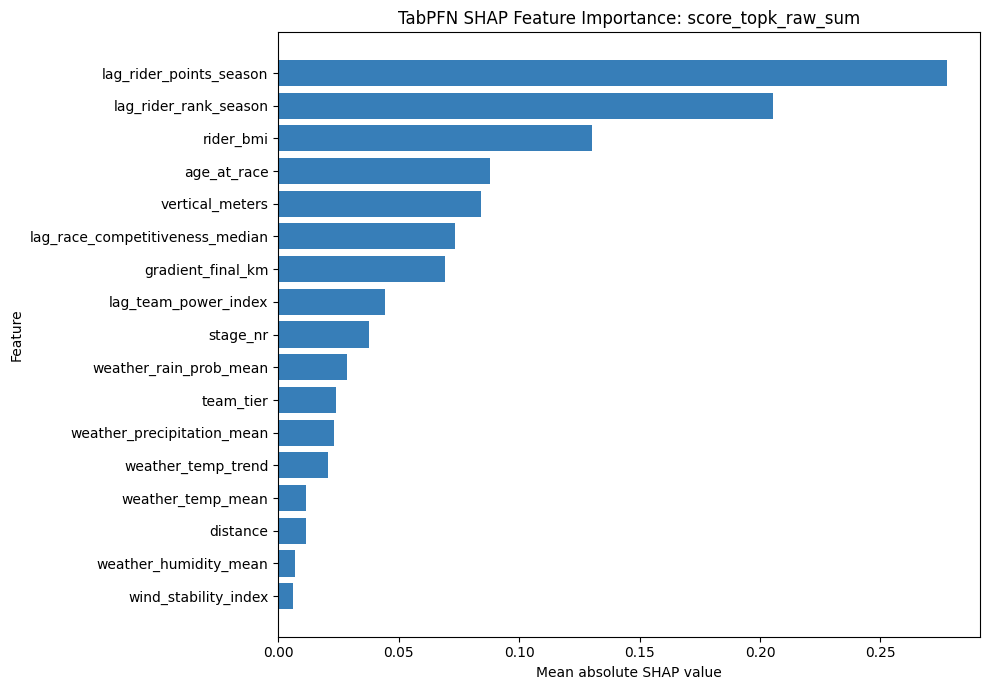

In [17]:
# Die wichtigsten Score-Features werden für den Plot ausgewählt.
plot_importance_score = importance_score.head(MAX_DISPLAY_FEATURES).sort_values("mean_abs_shap", ascending=True)

# Eine neue Figure für den Score-Plot wird erstellt.
fig, ax = plt.subplots(figsize=(10, 7))

# Die horizontalen Balken zeigen mittlere absolute SHAP-Werte.
ax.barh(plot_importance_score["feature"], plot_importance_score["mean_abs_shap"], color="#377eb8")

# Die x-Achse beschreibt die globale SHAP-Stärke.
ax.set_xlabel("Mean absolute SHAP value")

# Die y-Achse zeigt die Features.
ax.set_ylabel("Feature")

# Der Titel ordnet den Plot dem finalen Score zu.
ax.set_title("TabPFN SHAP Feature Importance: score_topk_raw_sum")

# Das Layout verhindert abgeschnittene Labels.
fig.tight_layout()

# Der Score-Plot wird gespeichert.
fig.savefig(CHART_DIR / "12-04_tabpfn_shap_importance_score.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Score-Plot wird angezeigt.
plt.show()


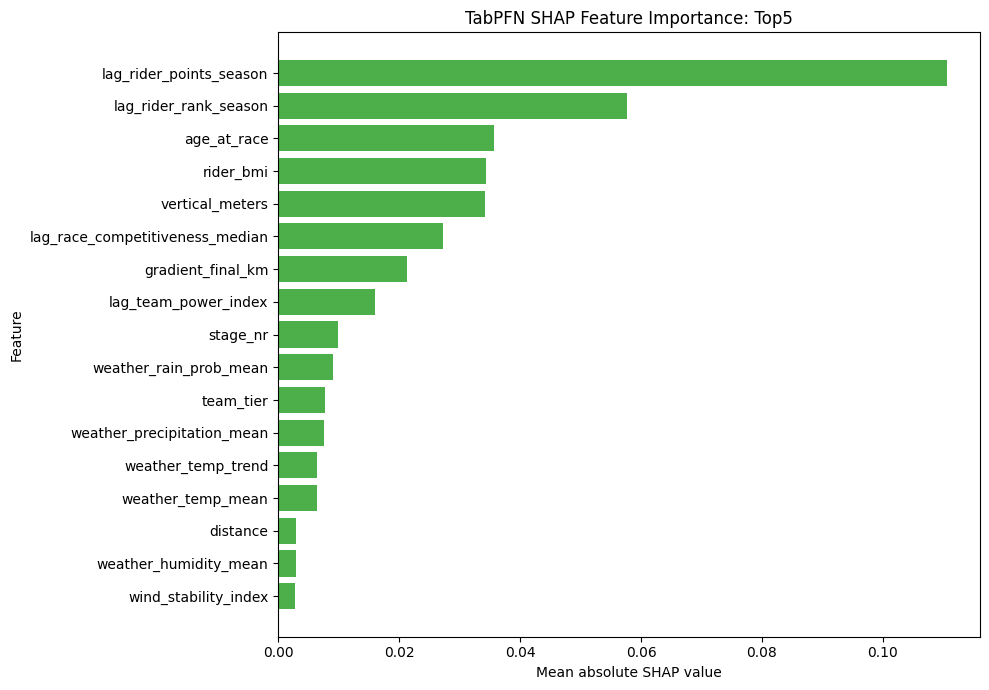

In [18]:
# Die wichtigsten Top5-Features werden für den Plot ausgewählt.
plot_importance_top5 = importance_top5.head(MAX_DISPLAY_FEATURES).sort_values("mean_abs_shap", ascending=True)

# Eine neue Figure für den Top5-Plot wird erstellt.
fig, ax = plt.subplots(figsize=(10, 7))

# Die horizontalen Balken zeigen mittlere absolute SHAP-Werte.
ax.barh(plot_importance_top5["feature"], plot_importance_top5["mean_abs_shap"], color="#4daf4a")

# Die x-Achse beschreibt die globale SHAP-Stärke.
ax.set_xlabel("Mean absolute SHAP value")

# Die y-Achse zeigt die Features.
ax.set_ylabel("Feature")

# Der Titel ordnet den Plot dem Top5-Modell zu.
ax.set_title("TabPFN SHAP Feature Importance: Top5")

# Das Layout verhindert abgeschnittene Labels.
fig.tight_layout()

# Der Top5-Plot wird gespeichert.
fig.savefig(CHART_DIR / "12-04_tabpfn_shap_importance_top5.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Top5-Plot wird angezeigt.
plt.show()


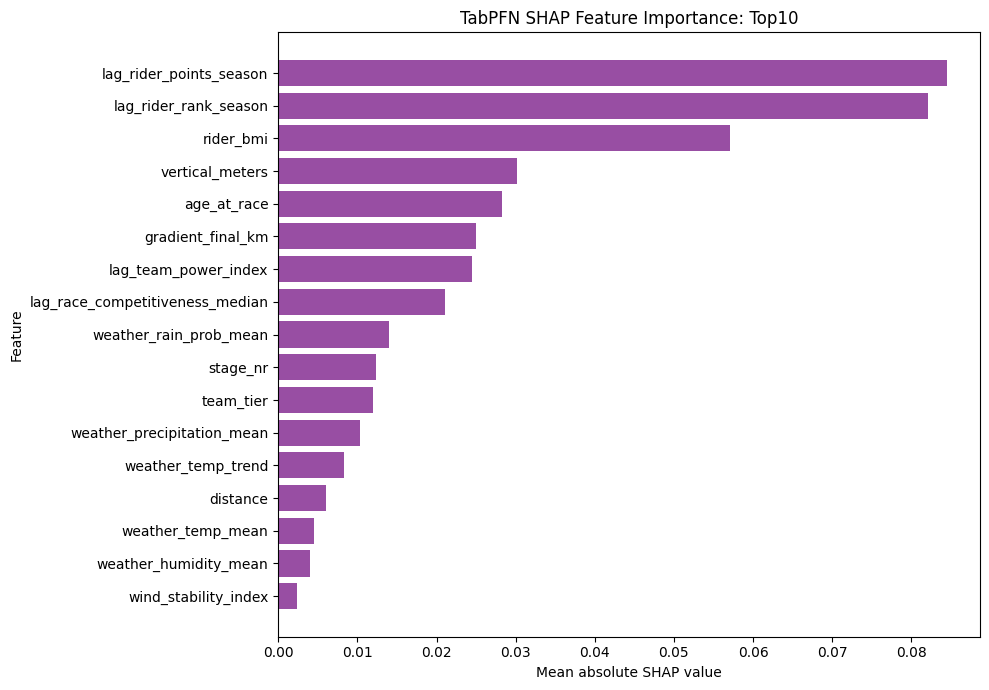

In [19]:
# Die wichtigsten Top10-Features werden für den Plot ausgewählt.
plot_importance_top10 = importance_top10.head(MAX_DISPLAY_FEATURES).sort_values("mean_abs_shap", ascending=True)

# Eine neue Figure für den Top10-Plot wird erstellt.
fig, ax = plt.subplots(figsize=(10, 7))

# Die horizontalen Balken zeigen mittlere absolute SHAP-Werte.
ax.barh(plot_importance_top10["feature"], plot_importance_top10["mean_abs_shap"], color="#984ea3")

# Die x-Achse beschreibt die globale SHAP-Stärke.
ax.set_xlabel("Mean absolute SHAP value")

# Die y-Achse zeigt die Features.
ax.set_ylabel("Feature")

# Der Titel ordnet den Plot dem Top10-Modell zu.
ax.set_title("TabPFN SHAP Feature Importance: Top10")

# Das Layout verhindert abgeschnittene Labels.
fig.tight_layout()

# Der Top10-Plot wird gespeichert.
fig.savefig(CHART_DIR / "12-04_tabpfn_shap_importance_top10.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Top10-Plot wird angezeigt.
plt.show()


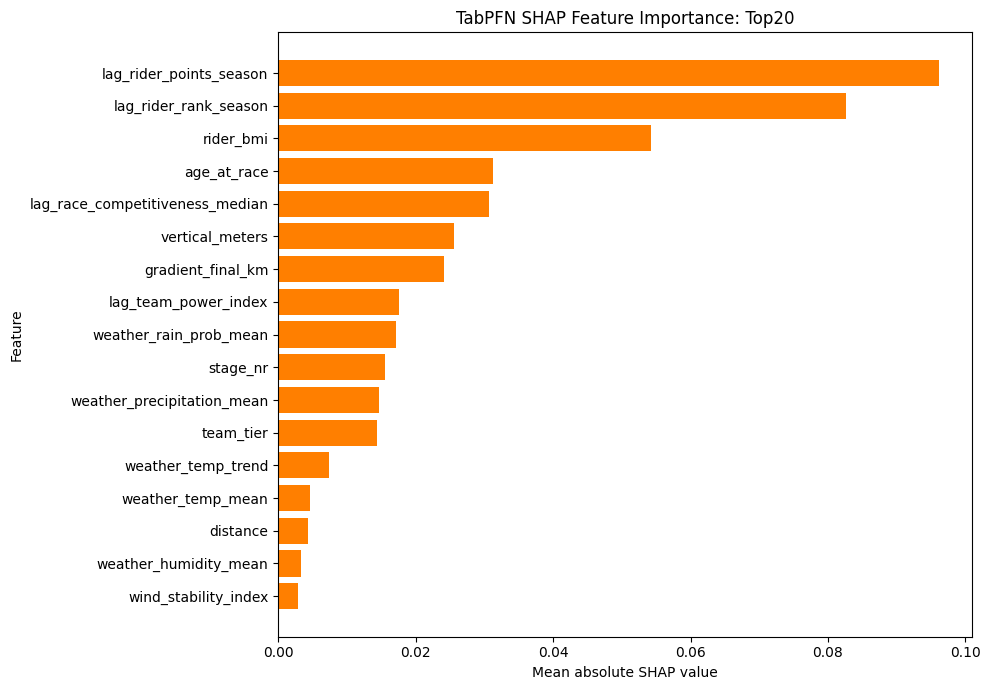

In [20]:
# Die wichtigsten Top20-Features werden für den Plot ausgewählt.
plot_importance_top20 = importance_top20.head(MAX_DISPLAY_FEATURES).sort_values("mean_abs_shap", ascending=True)

# Eine neue Figure für den Top20-Plot wird erstellt.
fig, ax = plt.subplots(figsize=(10, 7))

# Die horizontalen Balken zeigen mittlere absolute SHAP-Werte.
ax.barh(plot_importance_top20["feature"], plot_importance_top20["mean_abs_shap"], color="#ff7f00")

# Die x-Achse beschreibt die globale SHAP-Stärke.
ax.set_xlabel("Mean absolute SHAP value")

# Die y-Achse zeigt die Features.
ax.set_ylabel("Feature")

# Der Titel ordnet den Plot dem Top20-Modell zu.
ax.set_title("TabPFN SHAP Feature Importance: Top20")

# Das Layout verhindert abgeschnittene Labels.
fig.tight_layout()

# Der Top20-Plot wird gespeichert.
fig.savefig(CHART_DIR / "12-04_tabpfn_shap_importance_top20.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Top20-Plot wird angezeigt.
plt.show()


## Plotdaten für SHAP-Beeswarm und Waterfall vorbereiten

SHAP-Plots arbeiten am stabilsten mit numerischen Plotdaten. Die kategoriale Spalte `team_tier` wird deshalb für die Plot-Farbskala in Codes übersetzt. Die Modellberechnung selbst wurde aber weiterhin mit den originalen Feature-Daten durchgeführt.


In [21]:
# Die Plotdaten nutzen dieselbe numerische Matrix wie die SHAP-Berechnung.
X_plot_numeric = X_explain_shap[FEATURE_COLUMNS].copy()

# Eine lesbare Display-Kopie bewahrt die originalen Werte für Tabellen und Interpretation.
X_plot_display = X_explain[FEATURE_COLUMNS].astype(object).copy()

# Die Matrix ist bereits codiert; der Cast sichert den numerischen Plottyp ab.
X_plot_numeric = X_plot_numeric.astype(float)

# Das Score-Explanation-Objekt bündelt Score-SHAP-Werte, Basiswerte und Plotdaten.
explanation_score = shap.Explanation(values=shap_values_score, base_values=base_values_score, data=X_plot_numeric.to_numpy(), feature_names=FEATURE_COLUMNS, display_data=X_plot_display.to_numpy(), output_names="score_topk_raw_sum")

# Das Top5-Explanation-Objekt bündelt Top5-SHAP-Werte, Basiswerte und Plotdaten.
explanation_top5 = shap.Explanation(values=shap_values_top5, base_values=base_values_top5, data=X_plot_numeric.to_numpy(), feature_names=FEATURE_COLUMNS, display_data=X_plot_display.to_numpy(), output_names="top5")

# Das Top10-Explanation-Objekt bündelt Top10-SHAP-Werte, Basiswerte und Plotdaten.
explanation_top10 = shap.Explanation(values=shap_values_top10, base_values=base_values_top10, data=X_plot_numeric.to_numpy(), feature_names=FEATURE_COLUMNS, display_data=X_plot_display.to_numpy(), output_names="top10")

# Das Top20-Explanation-Objekt bündelt Top20-SHAP-Werte, Basiswerte und Plotdaten.
explanation_top20 = shap.Explanation(values=shap_values_top20, base_values=base_values_top20, data=X_plot_numeric.to_numpy(), feature_names=FEATURE_COLUMNS, display_data=X_plot_display.to_numpy(), output_names="top20")

# Die vorbereiteten Explanation-Objekte werden knapp bestätigt.
print("SHAP-Explanation-Objekte vorbereitet.")


SHAP-Explanation-Objekte vorbereitet.


## Beeswarm-Plots erzeugen

Beeswarm-Plots zeigen viele lokale SHAP-Werte gleichzeitig. Dadurch sieht man neben der globalen Wichtigkeit auch, ob hohe oder niedrige Feature-Werte eher positive oder negative Beiträge leisten.


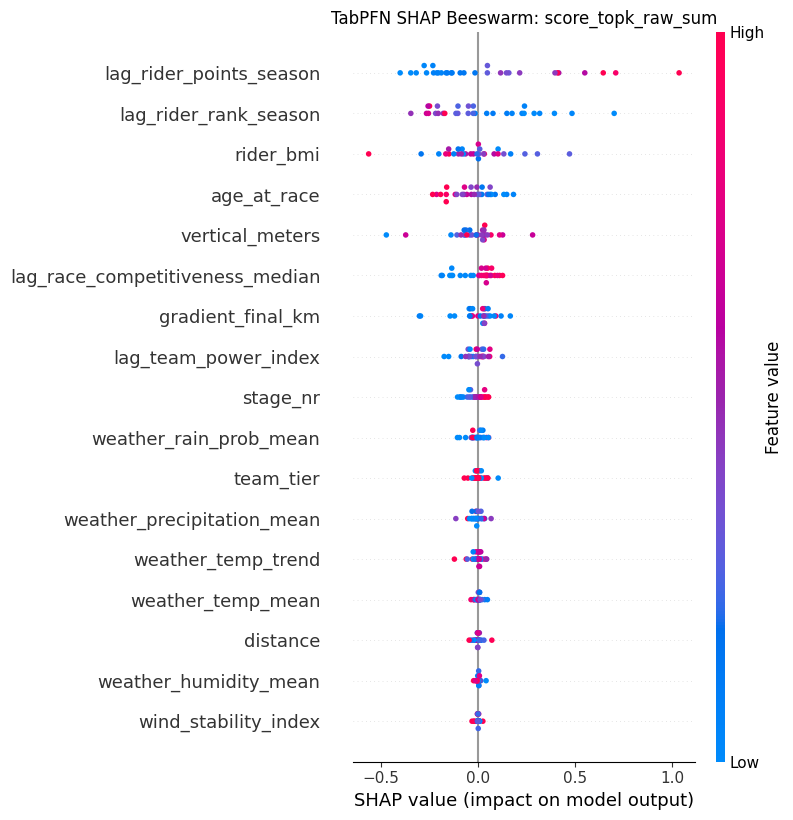

In [22]:
# Eine neue Figure für den Score-Beeswarm wird geöffnet.
plt.figure(figsize=(10, 8))

# Der Score-Beeswarm zeigt die globale Verteilung der Score-SHAP-Werte.
shap.plots.beeswarm(explanation_score, max_display=MAX_DISPLAY_FEATURES, show=False)

# Der Plot erhält einen sprechenden Titel.
plt.title("TabPFN SHAP Beeswarm: score_topk_raw_sum")

# Das Layout wird verdichtet.
plt.tight_layout()

# Der Score-Beeswarm wird gespeichert.
plt.savefig(CHART_DIR / "12-04_tabpfn_shap_beeswarm_score.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Plot wird angezeigt.
plt.show()


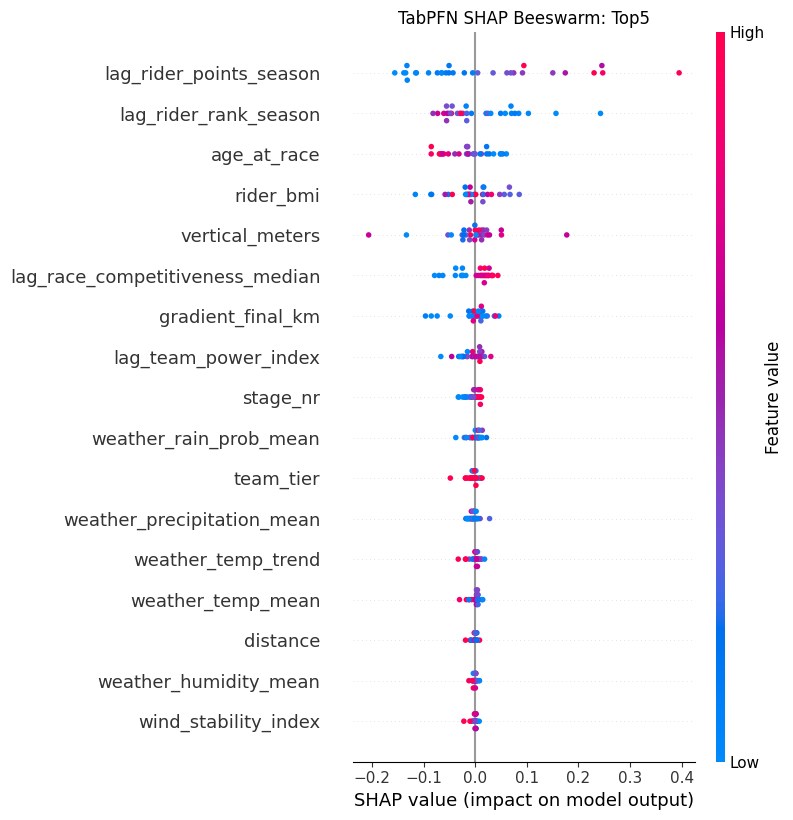

In [23]:
# Eine neue Figure für den Top5-Beeswarm wird geöffnet.
plt.figure(figsize=(10, 8))

# Der Top5-Beeswarm zeigt die lokale Verteilung der Top5-SHAP-Werte.
shap.plots.beeswarm(explanation_top5, max_display=MAX_DISPLAY_FEATURES, show=False)

# Der Plot erhält einen sprechenden Titel.
plt.title("TabPFN SHAP Beeswarm: Top5")

# Das Layout wird verdichtet.
plt.tight_layout()

# Der Top5-Beeswarm wird gespeichert.
plt.savefig(CHART_DIR / "12-04_tabpfn_shap_beeswarm_top5.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Plot wird angezeigt.
plt.show()


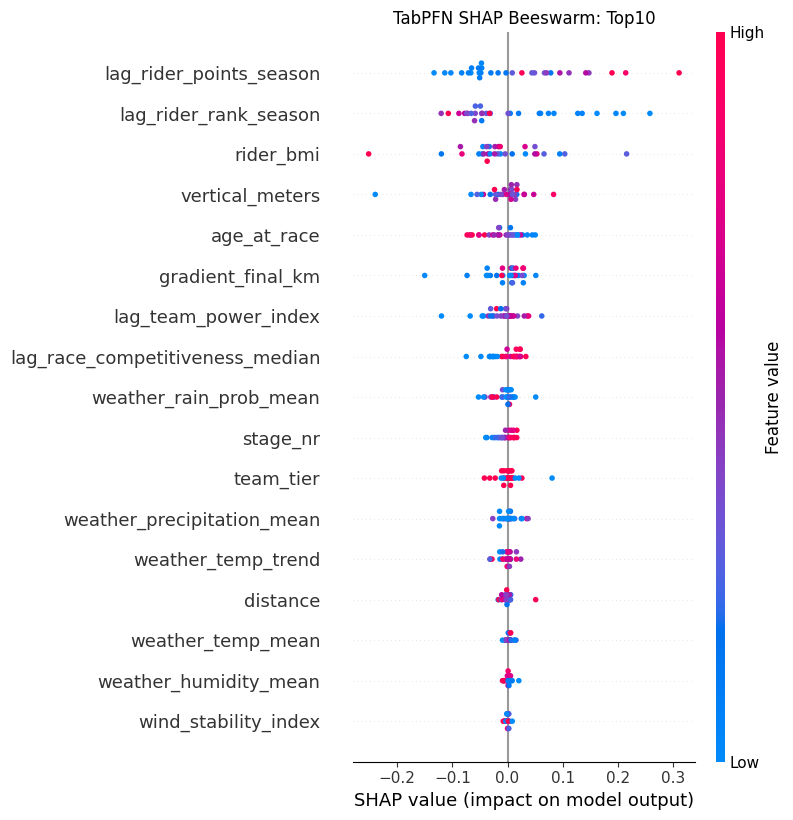

In [24]:
# Eine neue Figure für den Top10-Beeswarm wird geöffnet.
plt.figure(figsize=(10, 8))

# Der Top10-Beeswarm zeigt die lokale Verteilung der Top10-SHAP-Werte.
shap.plots.beeswarm(explanation_top10, max_display=MAX_DISPLAY_FEATURES, show=False)

# Der Plot erhält einen sprechenden Titel.
plt.title("TabPFN SHAP Beeswarm: Top10")

# Das Layout wird verdichtet.
plt.tight_layout()

# Der Top10-Beeswarm wird gespeichert.
plt.savefig(CHART_DIR / "12-04_tabpfn_shap_beeswarm_top10.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Plot wird angezeigt.
plt.show()


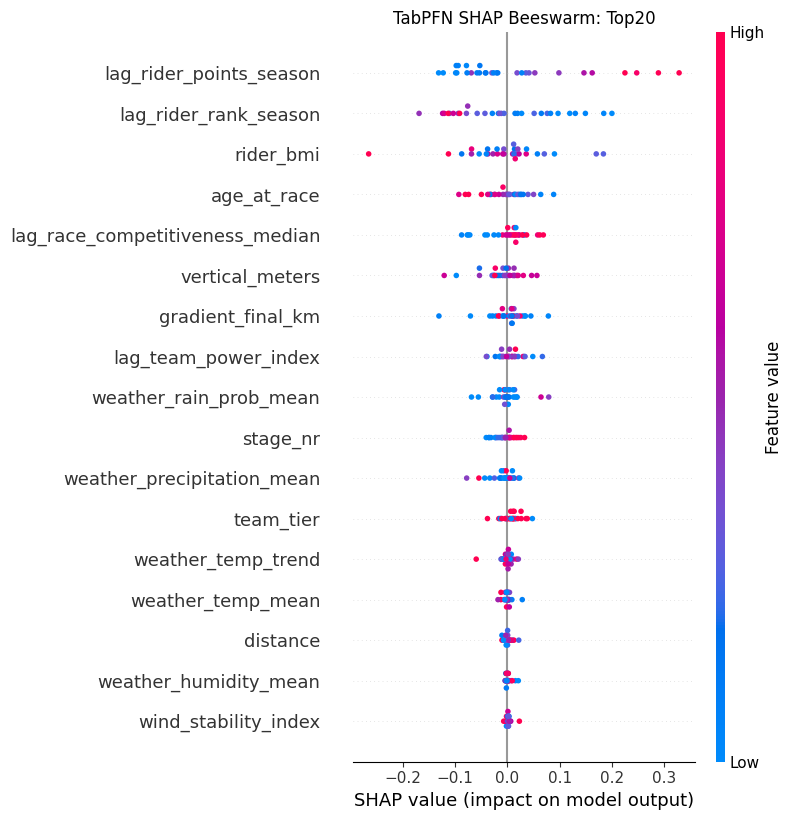

In [25]:
# Eine neue Figure für den Top20-Beeswarm wird geöffnet.
plt.figure(figsize=(10, 8))

# Der Top20-Beeswarm zeigt die lokale Verteilung der Top20-SHAP-Werte.
shap.plots.beeswarm(explanation_top20, max_display=MAX_DISPLAY_FEATURES, show=False)

# Der Plot erhält einen sprechenden Titel.
plt.title("TabPFN SHAP Beeswarm: Top20")

# Das Layout wird verdichtet.
plt.tight_layout()

# Der Top20-Beeswarm wird gespeichert.
plt.savefig(CHART_DIR / "12-04_tabpfn_shap_beeswarm_top20.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Plot wird angezeigt.
plt.show()


## Fünf wichtigste und drei unwichtigste Features auswählen

Die Detailinterpretation orientiert sich am finalen Score. Deshalb werden die fünf wichtigsten und drei unwichtigsten Features aus der Score-Importance ausgewählt.


In [26]:
# Die fünf wichtigsten Features werden aus der Score-Importance gelesen.
top5_features = importance_score.head(5)["feature"].tolist()

# Die drei unwichtigsten Features werden aus dem Ende der Score-Importance gelesen.
bottom3_features = importance_score.tail(3)["feature"].tolist()

# Die Fokusfeatures werden in einer Tabelle dokumentiert.
feature_focus = pd.DataFrame(
    [{"group": "top5_important", "feature": feature} for feature in top5_features]
    + [{"group": "bottom3_unimportant", "feature": feature} for feature in bottom3_features]
)

# Die Fokusfeature-Tabelle wird gespeichert.
feature_focus.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_focus.csv", index=False)

# Die Fokusfeature-Tabelle wird angezeigt.
display(feature_focus)


,group,feature
0,top5_important,lag_rider_points_season
1,top5_important,lag_rider_rank_season
2,top5_important,rider_bmi
3,top5_important,age_at_race
4,top5_important,vertical_meters
5,bottom3_unimportant,distance
6,bottom3_unimportant,weather_humidity_mean
7,bottom3_unimportant,wind_stability_index


## Target-Vergleich der Fokusfeatures

Ein Feature kann im Gesamtscore wichtig sein, aber in Top5, Top10 und Top20 unterschiedlich stark wirken. Deshalb werden die Fokusfeatures über alle vier Erklärungsebenen verglichen.


In [27]:
# Die Fokusfeatures werden aus der Top5-Importance herausgezogen.
focus_top5 = importance_top5[importance_top5["feature"].isin(top5_features + bottom3_features)].copy()

# Die Fokusfeatures werden aus der Top10-Importance herausgezogen.
focus_top10 = importance_top10[importance_top10["feature"].isin(top5_features + bottom3_features)].copy()

# Die Fokusfeatures werden aus der Top20-Importance herausgezogen.
focus_top20 = importance_top20[importance_top20["feature"].isin(top5_features + bottom3_features)].copy()

# Die Fokusfeatures werden aus der Score-Importance herausgezogen.
focus_score = importance_score[importance_score["feature"].isin(top5_features + bottom3_features)].copy()

# Alle Fokus-Tabellen werden zu einer Vergleichstabelle verbunden.
focus_comparison = pd.concat([focus_score, focus_top5, focus_top10, focus_top20], axis=0, ignore_index=True)

# Die Vergleichstabelle wird gespeichert.
focus_comparison.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_focus_feature_target_comparison.csv", index=False)

# Die Vergleichstabelle wird sortiert angezeigt.
display(focus_comparison.sort_values(["feature", "explanation"]))


,explanation,feature,mean_abs_shap,mean_signed_shap,importance_rank
3,score_topk_raw_sum,age_at_race,0.087733,-0.027067,4
20,top10,age_at_race,0.028290,-0.010587,5
27,top20,age_at_race,0.031280,-0.003535,4
10,top5,age_at_race,0.035679,-0.012945,3
5,score_topk_raw_sum,distance,0.011419,-0.000307,15
21,top10,distance,0.006034,0.000081,14
29,top20,distance,0.004316,0.000249,15
13,top5,distance,0.003010,-0.000638,15
0,score_topk_raw_sum,lag_rider_points_season,0.277485,0.048651,1
16,top10,lag_rider_points_season,0.084464,0.019013,1


## Dependence-Plots für Fokusfeatures

Dependence-Plots zeigen, wie konkrete Feature-Werte mit SHAP-Beiträgen zusammenhängen. Sie helfen dabei, die Richtung der wichtigsten und unwichtigsten Features im Score zu verstehen.

Die folgende Zelle bleibt linear: Sie läuft sichtbar über die ausgewählten Features und erzeugt je Feature einen Score-Dependence-Plot.


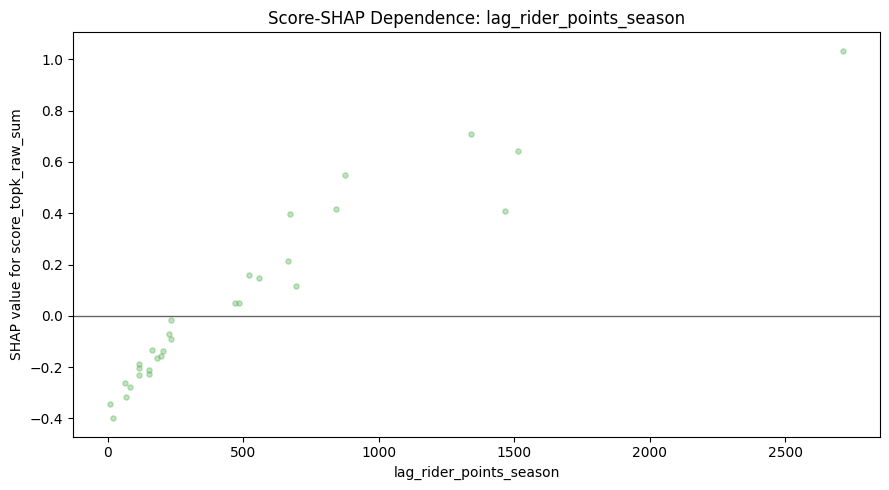

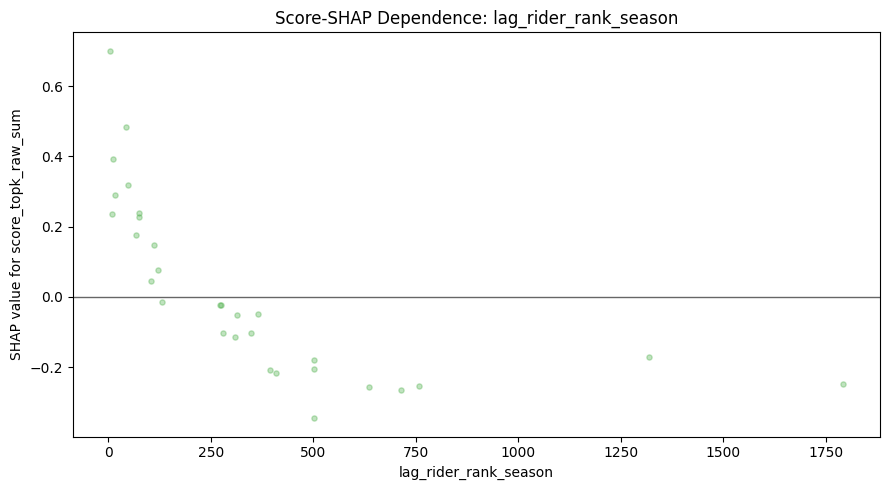

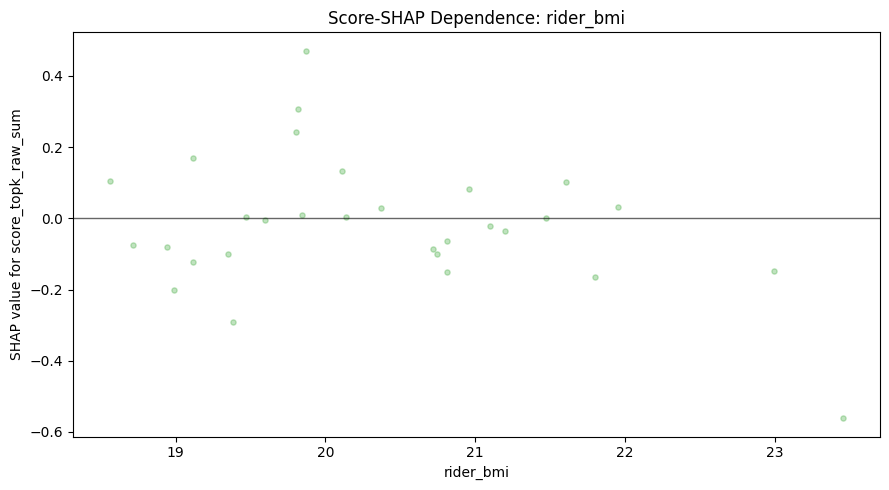

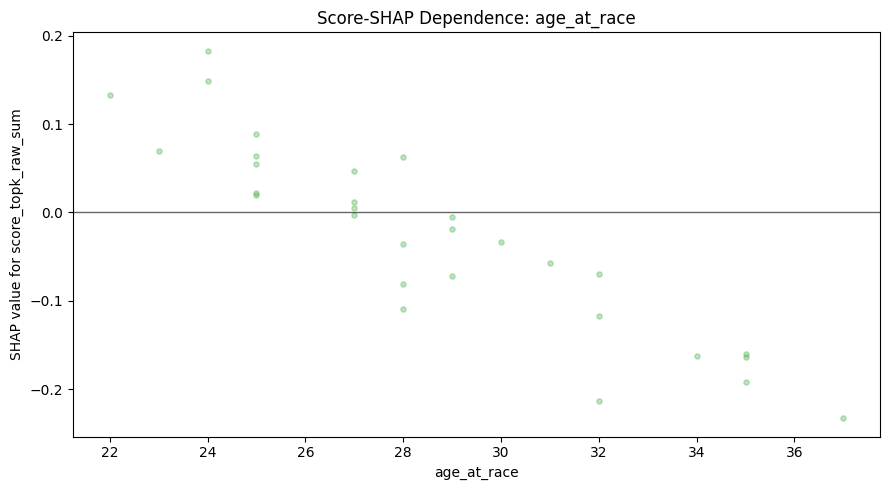

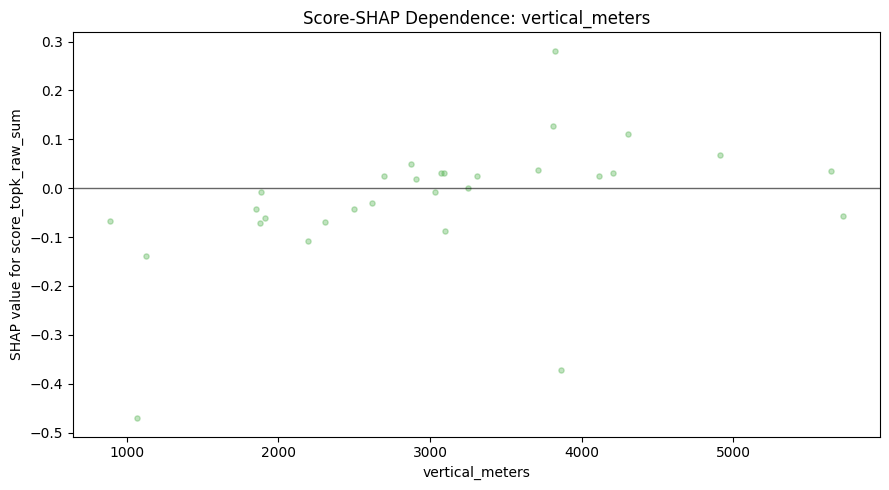

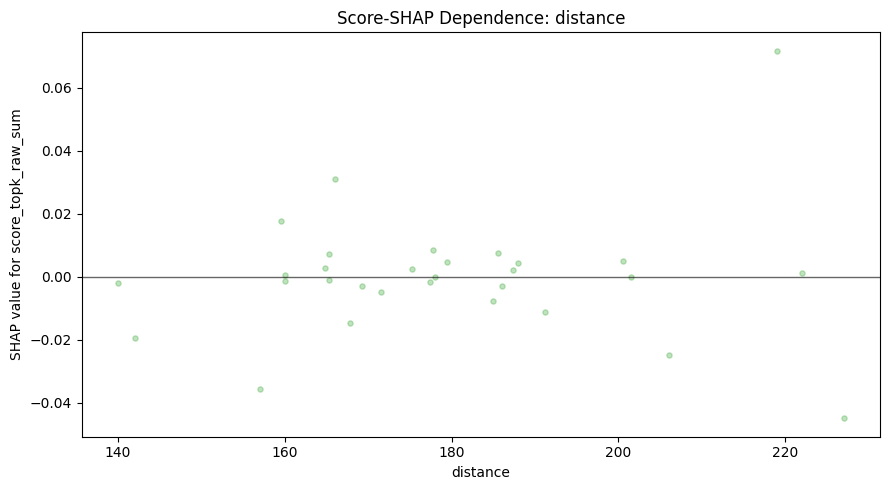

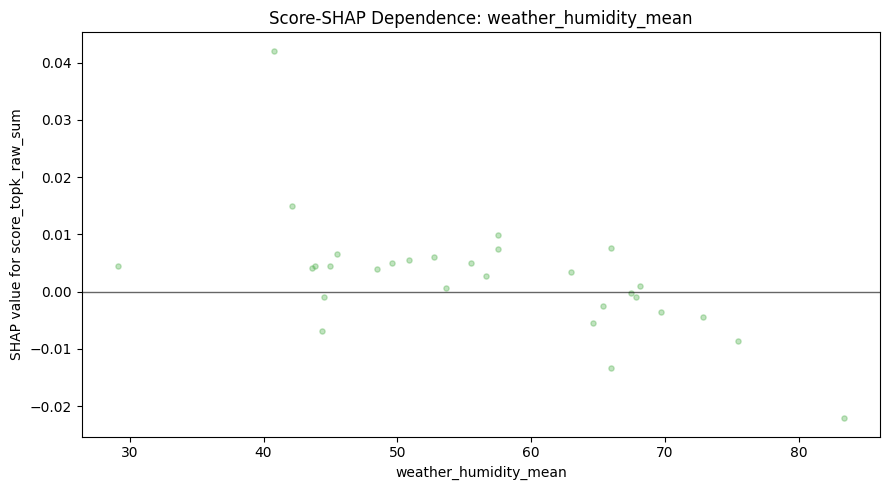

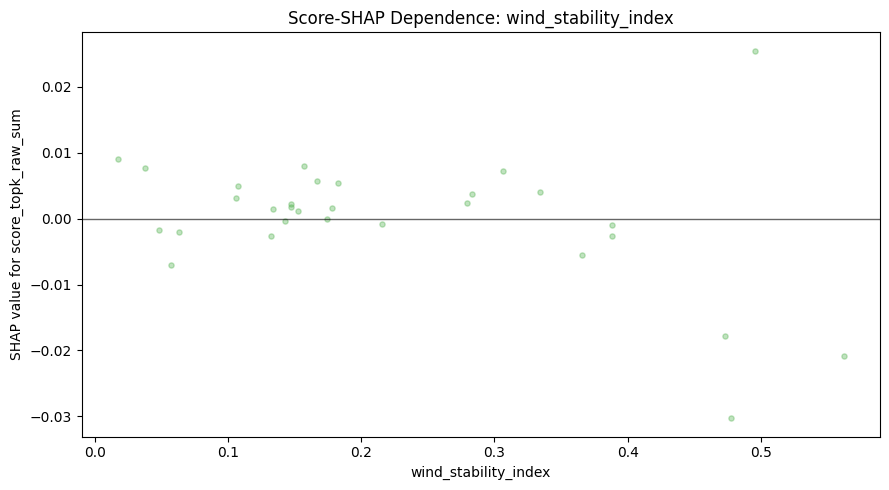

In [28]:
# Alle Fokusfeatures werden für Dependence-Plots zusammengeführt.
dependence_features = top5_features + bottom3_features

# Für jeden Fokusfeature-Namen wird ein eigener Plot erzeugt.
for feature in dependence_features:
    # Der Index des Features wird aus der festen Feature-Liste gelesen.
    feature_index = FEATURE_COLUMNS.index(feature)
    # Die x-Werte stammen aus den numerischen Plotdaten.
    x_values = X_plot_numeric[feature]
    # Die y-Werte sind die Score-SHAP-Beiträge des Features.
    y_values = shap_values_score[:, feature_index]
    # Eine neue Figure wird für dieses Feature geöffnet.
    fig, ax = plt.subplots(figsize=(9, 5))
    # Der Scatterplot zeigt Feature-Wert gegen SHAP-Beitrag.
    ax.scatter(x_values, y_values, alpha=0.35, s=14, color="#4daf4a")
    # Die Null-Linie trennt positive und negative Beiträge.
    ax.axhline(0, color="black", linewidth=1, alpha=0.6)
    # Die x-Achse wird mit dem Feature-Namen beschriftet.
    ax.set_xlabel(feature)
    # Die y-Achse zeigt den SHAP-Beitrag zum Score.
    ax.set_ylabel("SHAP value for score_topk_raw_sum")
    # Der Titel ordnet den Plot ein.
    ax.set_title(f"Score-SHAP Dependence: {feature}")
    # Das Layout verhindert abgeschnittene Achsentitel.
    fig.tight_layout()
    # Der Dateiname wird aus dem Feature-Namen erzeugt.
    safe_feature_name = feature.replace("/", "_").replace(" ", "_")
    # Der Dependence-Plot wird gespeichert.
    fig.savefig(CHART_DIR / f"12-04_tabpfn_shap_dependence_score_{safe_feature_name}.png", dpi=PLOT_DPI, bbox_inches="tight")
    # Der Plot wird angezeigt.
    plt.show()


## Lokale Fälle für Waterfall-Plots auswählen

Globale Plots erklären das Modellverhalten im Durchschnitt. Waterfall-Plots erklären einzelne Fälle.

Hier werden drei Fälle ausgewählt: der höchste vorhergesagte Score, der niedrigste vorhergesagte Score und der größte absolute Rangfehler.


In [29]:
# Die lokale Falltabelle startet mit den gespeicherten Predictions aus 12-03.
local_case_table = predictions_explain.reset_index(drop=True).copy()

# Die aus SHAP rekonstruierte Score-Prediction wird ergänzt.
local_case_table["score_reconstructed_from_shap"] = reconstructed_score

# Der absolute Rangfehler wird als einfache lokale Fehlerheuristik berechnet.
local_case_table["rank_error_abs"] = (
    pd.to_numeric(local_case_table["actual_rank"], errors="coerce")
    - pd.to_numeric(local_case_table["rank_topk_raw_sum"], errors="coerce")
).abs()

# Der Index der Zeile mit dem höchsten Score wird bestimmt.
highest_score_index = int(local_case_table["score_topk_raw_sum"].idxmax())

# Der Index der Zeile mit dem niedrigsten Score wird bestimmt.
lowest_score_index = int(local_case_table["score_topk_raw_sum"].idxmin())

# Der Index der Zeile mit dem größten absoluten Rangfehler wird bestimmt.
largest_rank_error_index = int(local_case_table["rank_error_abs"].idxmax())

# Die drei ausgewählten Fälle werden in einer Tabelle zusammengeführt.
local_cases = pd.DataFrame([
    {"case_name": "highest_score", "row_index": highest_score_index},
    {"case_name": "lowest_score", "row_index": lowest_score_index},
    {"case_name": "largest_rank_error", "row_index": largest_rank_error_index},
])

# Die wichtigsten Anzeige-Spalten werden festgelegt.
case_display_cols = ["meta_year", "meta_name", "meta_current_team", "meta_race", "stage_nr", "actual_rank", "rank_topk_raw_sum", "score_topk_raw_sum", "rank_error_abs"]

# Die lokalen Fälle werden mit Metadaten angezeigt.
display(local_case_table.loc[local_cases["row_index"], case_display_cols])


,meta_year,meta_name,meta_current_team,meta_race,stage_nr,actual_rank,rank_topk_raw_sum,score_topk_raw_sum,rank_error_abs
0,2024,Jonas Vingegaard,Team Visma | Lease a Bike,tour-de-france,1,16.0,4,2.442964,12.0
13,2024,Fabian Lienhard,Groupama - FDJ,giro-d-italia,15,115.0,139,0.043584,24.0
23,2024,Kasper Asgreen,Soudal Quick-Step,vuelta-a-espana,14,138.0,29,1.430639,109.0


## Waterfall-Plot: höchster Score

Dieser Plot erklärt die Fahrer-Etappen-Zeile mit dem höchsten vorhergesagten Score. Er zeigt, welche Features diese sehr hohe Modellbewertung nach oben treiben.


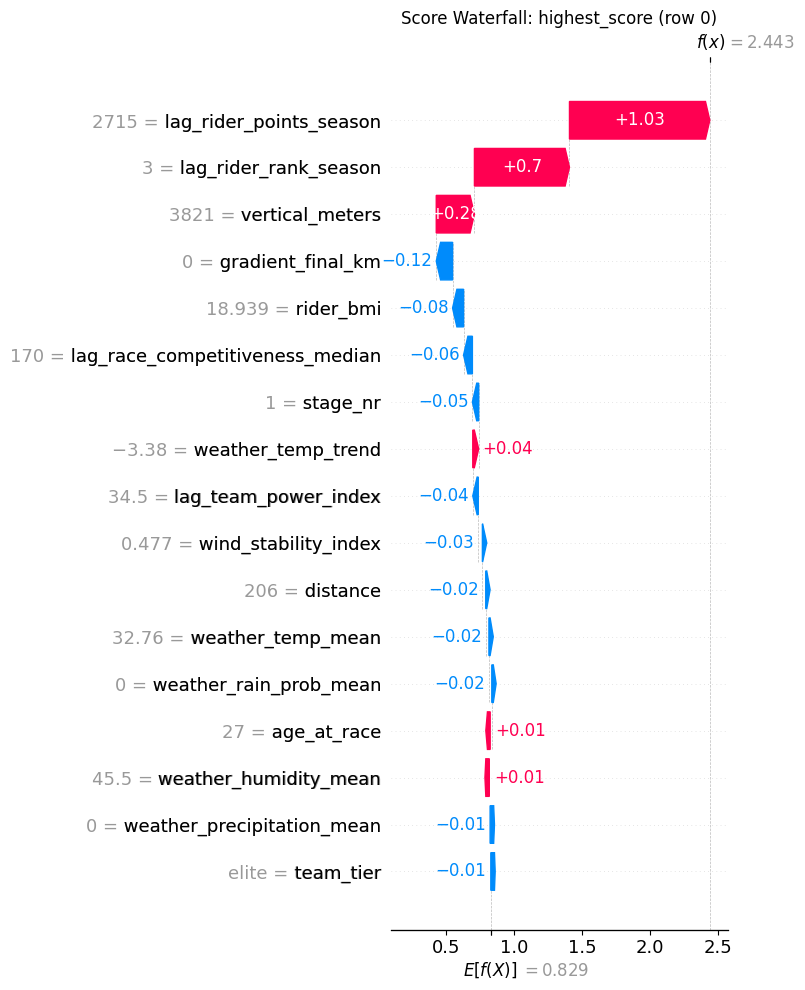

In [30]:
# Eine neue Figure wird für den höchsten Score geöffnet.
plt.figure(figsize=(9, 6))

# Der Waterfall-Plot erklärt die ausgewählte Zeile lokal.
shap.plots.waterfall(explanation_score[highest_score_index], max_display=MAX_DISPLAY_FEATURES, show=False)

# Der Titel benennt den lokalen Fall.
plt.title(f"Score Waterfall: highest_score (row {highest_score_index})")

# Das Layout wird verdichtet.
plt.tight_layout()

# Der Waterfall-Plot wird gespeichert.
plt.savefig(CHART_DIR / "12-04_tabpfn_shap_waterfall_score_highest_score.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Plot wird angezeigt.
plt.show()


## Waterfall-Plot: niedrigster Score

Dieser Plot erklärt die Fahrer-Etappen-Zeile mit dem niedrigsten vorhergesagten Score. Er zeigt, welche Features den Score besonders niedrig halten.


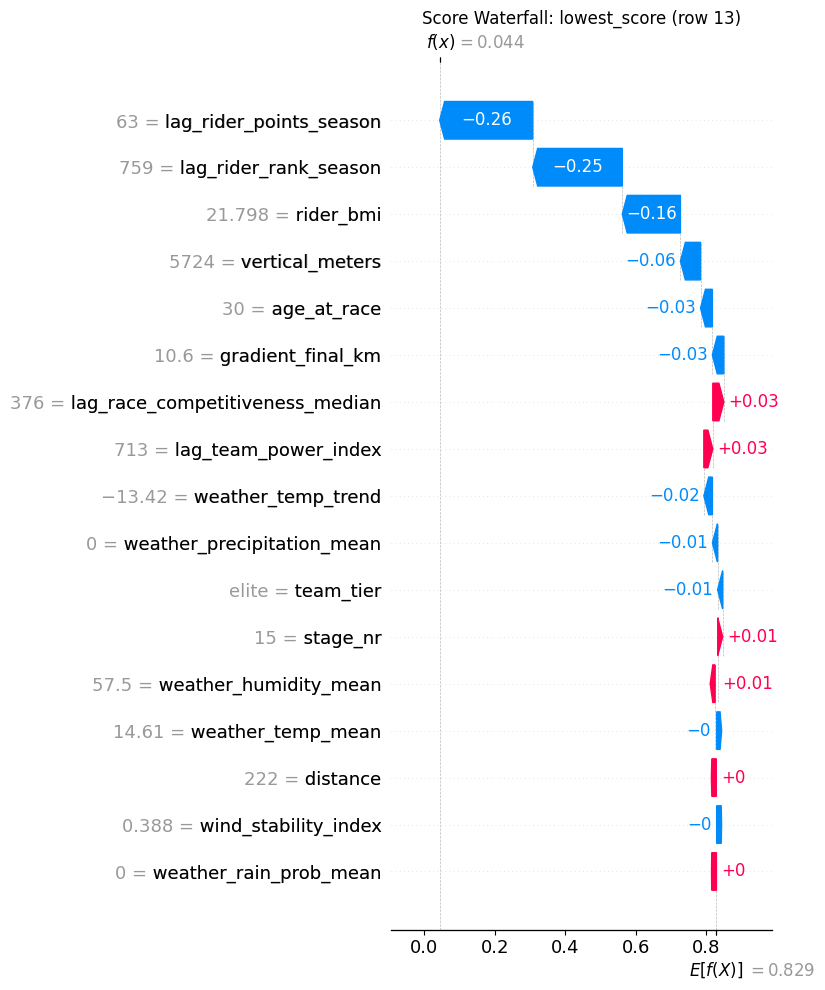

In [31]:
# Eine neue Figure wird für den niedrigsten Score geöffnet.
plt.figure(figsize=(9, 6))

# Der Waterfall-Plot erklärt die ausgewählte Zeile lokal.
shap.plots.waterfall(explanation_score[lowest_score_index], max_display=MAX_DISPLAY_FEATURES, show=False)

# Der Titel benennt den lokalen Fall.
plt.title(f"Score Waterfall: lowest_score (row {lowest_score_index})")

# Das Layout wird verdichtet.
plt.tight_layout()

# Der Waterfall-Plot wird gespeichert.
plt.savefig(CHART_DIR / "12-04_tabpfn_shap_waterfall_score_lowest_score.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Plot wird angezeigt.
plt.show()


## Waterfall-Plot: größter Rangfehler

Dieser Plot erklärt einen Fall, bei dem die vorhergesagte Rangposition besonders stark vom tatsächlichen Rang abweicht. Solche Fälle sind hilfreich, um Modellgrenzen sichtbar zu machen.


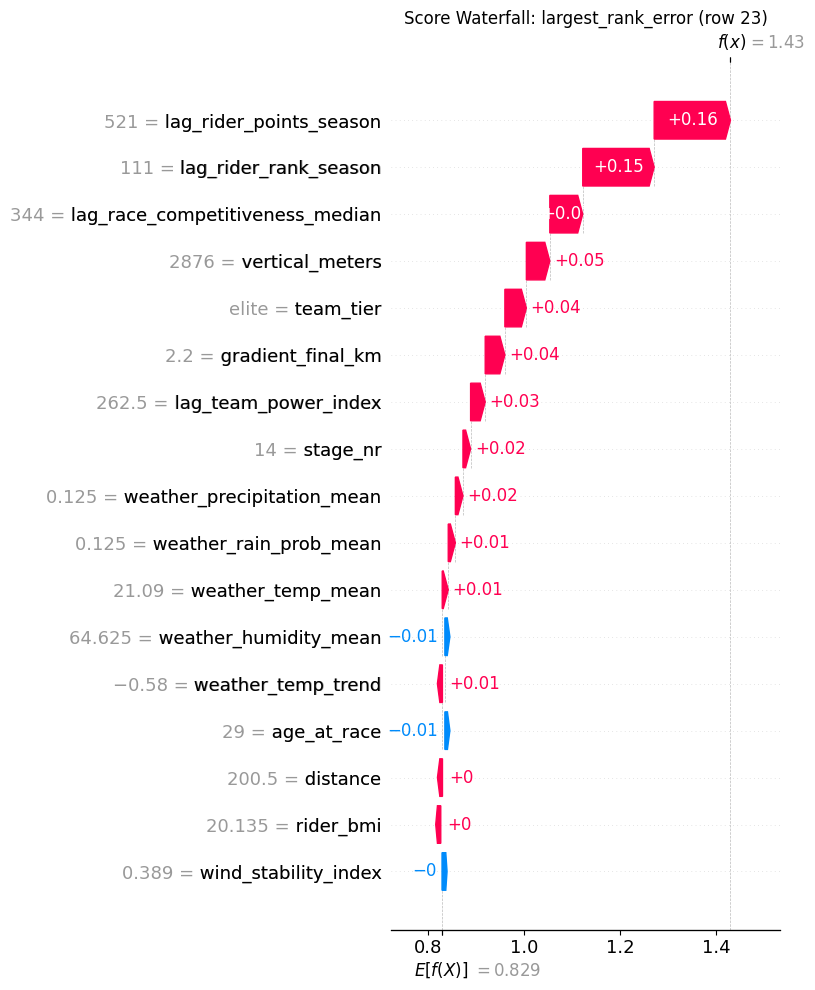

In [32]:
# Eine neue Figure wird für den größten Rangfehler geöffnet.
plt.figure(figsize=(9, 6))

# Der Waterfall-Plot erklärt die ausgewählte Zeile lokal.
shap.plots.waterfall(explanation_score[largest_rank_error_index], max_display=MAX_DISPLAY_FEATURES, show=False)

# Der Titel benennt den lokalen Fall.
plt.title(f"Score Waterfall: largest_rank_error (row {largest_rank_error_index})")

# Das Layout wird verdichtet.
plt.tight_layout()

# Der Waterfall-Plot wird gespeichert.
plt.savefig(CHART_DIR / "12-04_tabpfn_shap_waterfall_score_largest_rank_error.png", dpi=PLOT_DPI, bbox_inches="tight")

# Der Plot wird angezeigt.
plt.show()


## Fünf wichtigste Features interpretieren

Die folgenden Tabellen liefern die numerische Grundlage für die fachliche Interpretation der fünf wichtigsten Score-Features. Entscheidend sind die Score-Rangfolge, die Stärke des mittleren absoluten Beitrags und der Vergleich mit Top5, Top10 und Top20.


In [33]:
# Die fünf wichtigsten Features werden aus der Vergleichstabelle gefiltert.
top_feature_interpretation = focus_comparison[focus_comparison["feature"].isin(top5_features)].copy()

# Eine explizite Reihenfolge nach Score-Importance wird vorbereitet.
top_feature_order = {feature: order for order, feature in enumerate(top5_features, start=1)}

# Die Score-Reihenfolge wird als Spalte ergänzt.
top_feature_interpretation["score_feature_order"] = top_feature_interpretation["feature"].map(top_feature_order)

# Die Tabelle wird zuerst nach Score-Reihenfolge und dann nach Erklärungsebene sortiert.
top_feature_interpretation = top_feature_interpretation.sort_values(["score_feature_order", "explanation"])

# Die Tabelle wird gespeichert.
top_feature_interpretation.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_top5_feature_interpretation_table.csv", index=False)

# Die Tabelle wird angezeigt.
display(top_feature_interpretation)


,explanation,feature,mean_abs_shap,mean_signed_shap,importance_rank,score_feature_order
0,score_topk_raw_sum,lag_rider_points_season,0.277485,0.048651,1,1
16,top10,lag_rider_points_season,0.084464,0.019013,1,1
24,top20,lag_rider_points_season,0.096123,0.015287,1,1
8,top5,lag_rider_points_season,0.110543,0.014351,1,1
1,score_topk_raw_sum,lag_rider_rank_season,0.205323,0.017012,2,2
17,top10,lag_rider_rank_season,0.082100,0.010545,2,2
25,top20,lag_rider_rank_season,0.082601,-0.001637,2,2
9,top5,lag_rider_rank_season,0.057665,0.008103,2,2
2,score_topk_raw_sum,rider_bmi,0.130101,-0.017378,3,3
18,top10,rider_bmi,0.057144,-0.010186,3,3


## Drei unwichtigste Features interpretieren

Die drei unwichtigsten Features haben im Modell durchschnittlich die geringsten absoluten SHAP-Beiträge zum Score.

Das bedeutet nicht automatisch, dass sie fachlich irrelevant sind. Es bedeutet zunächst nur, dass dieses konkrete TabPFN-Modell diese Features im Testkontext wenig für seine Score-Variation nutzt.


In [34]:
# Die drei unwichtigsten Features werden aus der Vergleichstabelle gefiltert.
bottom_feature_interpretation = focus_comparison[focus_comparison["feature"].isin(bottom3_features)].copy()

# Eine explizite Reihenfolge nach Score-Importance wird vorbereitet.
bottom_feature_order = {feature: order for order, feature in enumerate(bottom3_features, start=1)}

# Die Score-Reihenfolge wird als Spalte ergänzt.
bottom_feature_interpretation["score_feature_order"] = bottom_feature_interpretation["feature"].map(bottom_feature_order)

# Die Tabelle wird zuerst nach Score-Reihenfolge und dann nach Erklärungsebene sortiert.
bottom_feature_interpretation = bottom_feature_interpretation.sort_values(["score_feature_order", "explanation"])

# Die Tabelle wird gespeichert.
bottom_feature_interpretation.to_csv(SHAP_OUTPUT_DIR / "tabpfn_shap_bottom3_feature_interpretation_table.csv", index=False)

# Die Tabelle wird angezeigt.
display(bottom_feature_interpretation)


,explanation,feature,mean_abs_shap,mean_signed_shap,importance_rank,score_feature_order
5,score_topk_raw_sum,distance,0.011419,-0.000307,15,1
21,top10,distance,0.006034,0.000081,14,1
29,top20,distance,0.004316,0.000249,15,1
13,top5,distance,0.003010,-0.000638,15,1
6,score_topk_raw_sum,weather_humidity_mean,0.006942,0.002323,16,2
22,top10,weather_humidity_mean,0.003989,0.001503,16,2
30,top20,weather_humidity_mean,0.003260,0.001256,16,2
14,top5,weather_humidity_mean,0.002955,-0.000435,16,2
7,score_topk_raw_sum,wind_stability_index,0.006252,0.000073,17,3
23,top10,wind_stability_index,0.002334,-0.000520,17,3


## Finale Artefaktübersicht

Am Ende wird geprüft, welche Tabellen und Plots aus dem Notebook entstanden sind. Diese Übersicht hilft beim späteren Verweis in Dokumentation oder Präsentation.


In [35]:
# Die Artefaktübersicht startet als einfache Liste von Dicts.
artifact_rows = []

# Die vier Feature-Importance-Tabellen werden geprüft.
artifact_rows.append({"artifact": "tabpfn_shap_feature_importance_top5.csv", "path": str(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top5.csv"), "exists": (SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top5.csv").exists()})
artifact_rows.append({"artifact": "tabpfn_shap_feature_importance_top10.csv", "path": str(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top10.csv"), "exists": (SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top10.csv").exists()})
artifact_rows.append({"artifact": "tabpfn_shap_feature_importance_top20.csv", "path": str(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top20.csv"), "exists": (SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_top20.csv").exists()})
artifact_rows.append({"artifact": "tabpfn_shap_feature_importance_score.csv", "path": str(SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_score.csv"), "exists": (SHAP_OUTPUT_DIR / "tabpfn_shap_feature_importance_score.csv").exists()})

# Die technischen Check-Tabellen werden geprüft.
artifact_rows.append({"artifact": "tabpfn_shap_prediction_check.csv", "path": str(SHAP_OUTPUT_DIR / "tabpfn_shap_prediction_check.csv"), "exists": (SHAP_OUTPUT_DIR / "tabpfn_shap_prediction_check.csv").exists()})
artifact_rows.append({"artifact": "tabpfn_shap_additivity_check.csv", "path": str(SHAP_OUTPUT_DIR / "tabpfn_shap_additivity_check.csv"), "exists": (SHAP_OUTPUT_DIR / "tabpfn_shap_additivity_check.csv").exists()})
artifact_rows.append({"artifact": "tabpfn_shap_score_additivity_check.csv", "path": str(SHAP_OUTPUT_DIR / "tabpfn_shap_score_additivity_check.csv"), "exists": (SHAP_OUTPUT_DIR / "tabpfn_shap_score_additivity_check.csv").exists()})

# Die wichtigsten Score-Plots werden geprüft.
artifact_rows.append({"artifact": "12-04_tabpfn_shap_importance_score.png", "path": str(CHART_DIR / "12-04_tabpfn_shap_importance_score.png"), "exists": (CHART_DIR / "12-04_tabpfn_shap_importance_score.png").exists()})
artifact_rows.append({"artifact": "12-04_tabpfn_shap_beeswarm_score.png", "path": str(CHART_DIR / "12-04_tabpfn_shap_beeswarm_score.png"), "exists": (CHART_DIR / "12-04_tabpfn_shap_beeswarm_score.png").exists()})
artifact_rows.append({"artifact": "12-04_tabpfn_shap_waterfall_score_highest_score.png", "path": str(CHART_DIR / "12-04_tabpfn_shap_waterfall_score_highest_score.png"), "exists": (CHART_DIR / "12-04_tabpfn_shap_waterfall_score_highest_score.png").exists()})
artifact_rows.append({"artifact": "12-04_tabpfn_shap_waterfall_score_lowest_score.png", "path": str(CHART_DIR / "12-04_tabpfn_shap_waterfall_score_lowest_score.png"), "exists": (CHART_DIR / "12-04_tabpfn_shap_waterfall_score_lowest_score.png").exists()})
artifact_rows.append({"artifact": "12-04_tabpfn_shap_waterfall_score_largest_rank_error.png", "path": str(CHART_DIR / "12-04_tabpfn_shap_waterfall_score_largest_rank_error.png"), "exists": (CHART_DIR / "12-04_tabpfn_shap_waterfall_score_largest_rank_error.png").exists()})

# Aus der Liste wird eine DataFrame-Tabelle gebaut.
artifact_table = pd.DataFrame(artifact_rows)

# Die Artefaktübersicht wird angezeigt.
display(artifact_table)


,artifact,path,exists
0,tabpfn_shap_feature_importance_top5.csv,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
1,tabpfn_shap_feature_importance_top10.csv,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
2,tabpfn_shap_feature_importance_top20.csv,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
3,tabpfn_shap_feature_importance_score.csv,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
4,tabpfn_shap_prediction_check.csv,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
5,tabpfn_shap_additivity_check.csv,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
6,tabpfn_shap_score_additivity_check.csv,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
7,12-04_tabpfn_shap_importance_score.png,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
8,12-04_tabpfn_shap_beeswarm_score.png,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
9,12-04_tabpfn_shap_waterfall_score_highest_scor...,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True


## Methodisches Fazit

Dieses Notebook erklärt das Verhalten der finalen TabPFN-Standardmodelle aus `12-03`. Die SHAP-Werte beschreiben, welche Features die Modelloutputs beeinflussen. Sie sind keine kausalen Beweise über den realen Radsport.

Die zentrale Interpretation sollte sich daher auf drei Ebenen stützen:

1. globale Score-Importance,
2. Unterschiede zwischen Top5, Top10 und Top20,
3. lokale Beispiele über Waterfall-Plots.
